# VXN – Volatilitätsbasierte Frühindikatoren für ein Ampelsystem

### Eine explorative Datenanalyse des VXN (CBOE Nasdaq-100 Volatility Index)

Diese Analyse überträgt die Methodik des VIX-Notebooks auf den **VXN** und
untersucht neun Hypothesen zur Aussagekraft dieses Volatilitätsindex sowie
verwandter Kennzahlen als Bausteine für ein indikatorbasiertes **Ampelsystem**
(Grün = ruhiges Fahrwasser, Gelb = angespannt, Rot = Ausnahmezustand). Der VXN
bezieht sich dabei auf seinen eigenen zugrunde liegenden Aktienindex, den
**Nasdaq-100** – nicht auf den S&P 500. Ziel ist die Identifikation robuster
Signale sowie die datenbasierte Herleitung VXN-spezifischer Ampel-Schwellen.

Jede Hypothese wird in einheitlichen Schritten behandelt: Vorstellung und
Motivation, statistische bzw. grafische Auswertung, Interpretation der
Ergebnisse sowie eine Einschätzung der
praktischen Relevanz für das Ampelsystem.

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse
5. Einordnung und Handlungsempfehlungen
6. Ampel-Systematik auf Basis des VXN
7. Was-wäre-wenn-Analyse
8. Export der Ergebnisse
9. Zusammenfassung


## 1. Datenbezug und Aufbereitung

Grundlage der Analyse sind historische Tageskursdaten des VXN sowie des
Nasdaq-100 als Vergleichsindex. Dieser Abschnitt beschreibt die verwendeten
Software-Werkzeuge und den Datenbezug.


### 1.1 Verwendete Bibliotheken und Konfiguration

- **pandas** – Datenstrukturen und -verarbeitung (tabellarische Zeitreihen).
- **numpy** – numerische Berechnungen.
- **matplotlib** / **seaborn** – grafische Auswertung.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

import yfinance as yf

# Ampel-Farben für konsistente Plots
COLOR_GREEN = "#2ca02c"
COLOR_YELLOW = "#f2c811"
COLOR_RED = "#d62728"

### 1.2 Datenbezug

Die Rohdaten werden direkt in diesem Notebook über die Programmier-
schnittstelle von Yahoo Finance (`yfinance`) bezogen (Volatilitätsindex
mit Ticker `^VXN`, Aktienindex Nasdaq-100 mit Ticker `^NDX`,
tägliche OHLC-Daten ab dem 01.01.2007). Der Zeitraum ab 2007 schließt die
globale Finanzkrise 2008 als Stresstest mit ein.


In [2]:
def lade_yahoo(ticker: str, start: str) -> pd.DataFrame:
    '''Lädt tägliche OHLC-Daten von Yahoo Finance und reduziert auf eine
    einfache Spaltenebene (yfinance liefert bei Einzeltickern gelegentlich
    einen MultiIndex in den Spalten).'''
    raw = yf.download(ticker, start=start, auto_adjust=False, actions=False, progress=False)
    if raw.empty:
        raise ValueError(f"Keine Daten für '{ticker}' erhalten - Internetverbindung prüfen.")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns.name = None
    raw.index.name = "Date"
    return raw


vxn = lade_yahoo("^VXN", "2007-01-01")
nasdaq100 = lade_yahoo("^NDX", "2007-01-01")

print("VXN:", vxn.shape, vxn.index.min().date(), "-", vxn.index.max().date())
print("Nasdaq-100:", nasdaq100.shape, nasdaq100.index.min().date(), "-", nasdaq100.index.max().date())

vxn.head()

VXN: (4935, 6) 2007-01-03 - 2026-08-19
Nasdaq-100: (4938, 6) 2007-01-03 - 2026-08-19


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2007-01-03,17.500000,17.500000,18.420000,16.290001,16.969999,0
2007-01-04,16.990000,16.990000,17.860001,16.920000,17.580000,0
2007-01-05,17.900000,17.900000,18.290001,17.200001,17.209999,0
2007-01-08,18.350000,18.350000,18.950001,18.190001,18.209999,0
2007-01-09,17.889999,17.889999,18.790001,17.330000,18.340000,0


## 2. Datenbereinigung und Plausibilisierung

Vor der eigentlichen Analyse werden die Rohdaten systematisch auf typische
Qualitätsprobleme geprüft und anschließend zu einem gemeinsamen Analyse-
Datensatz zusammengeführt.


### 2.1 Datenqualitätsprüfung

Geprüft werden fehlende Werte, doppelte Datumseinträge sowie abweichende
Handelstage zwischen den beiden Zeitreihen (z. B. durch unterschiedliche
Feiertagskalender bei Yahoo Finance).


In [3]:
print("Fehlende Werte VXN:\
", vxn.isna().sum())
print("\
Fehlende Werte Nasdaq-100:\
", nasdaq100.isna().sum())
print("\
Duplizierte Indexwerte VXN:", vxn.index.duplicated().sum())
print("Duplizierte Indexwerte Nasdaq-100:", nasdaq100.index.duplicated().sum())

only_in_vxn = vxn.index.difference(nasdaq100.index)
only_in_nasdaq100 = nasdaq100.index.difference(vxn.index)
print(f"\
Handelstage nur im VXN: {len(only_in_vxn)}")
print(f"Handelstage nur im Nasdaq-100: {len(only_in_nasdaq100)}")

Fehlende Werte VXN: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Fehlende Werte Nasdaq-100: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Duplizierte Indexwerte VXN: 0
Duplizierte Indexwerte Nasdaq-100: 0
Handelstage nur im VXN: 0
Handelstage nur im Nasdaq-100: 3


### 2.2 Kombinierter Analyse-Datensatz und Zielgrößen

Beide Zeitreihen werden über die gemeinsamen Handelstage verknüpft (inner
join). Zusätzlich werden die tägliche Nasdaq-100-Rendite (`nasdaq100_return`, in %)
sowie die tägliche VXN-Veränderung (`vxn_change`, in Punkten) als abgeleitete
Größen berechnet.


In [4]:
df = pd.DataFrame({
    "vxn_close": vxn["Close"],
    "nasdaq100_close": nasdaq100["Close"],
}).dropna()

df["nasdaq100_return"] = df["nasdaq100_close"].pct_change() * 100  # in %
df["vxn_change"] = df["vxn_close"].diff()

print(f"Gemeinsame Handelstage: {len(df)}")
df.describe()

Gemeinsame Handelstage: 4935


,vxn_close,nasdaq100_close,nasdaq100_return,vxn_change
count,4935.000000,4935.000000,4934.000000,4934.000000
mean,22.668944,8068.715124,0.067409,0.000888
std,8.415949,7052.817983,1.428567,1.781699
min,10.310000,1036.510010,-12.193223,-15.990002
25%,16.915000,2376.255005,-0.529924,-0.770000
50%,20.459999,4819.899902,0.115759,-0.099998
75%,26.415000,12603.319824,0.763966,0.630000
max,80.639999,30660.599609,12.579933,28.240002


## 3. Methodik und Hypothesenübersicht


### 3.1 Ampel-Logik und statistische Referenzgrößen

Als gemeinsame Referenzgröße für die vertiefenden Hypothesen dient der
VXN-Schwellenwert **33** – die datenbasiert (Abschnitt 4.4) hergeleitete
Grenze für den „Ausnahmezustand" (Rot). Anders als beim VIX (Faustregel 20/30)
werden die Schwellen 23/33 aus der VXN-eigenen Verteilung abgeleitet,
sodass sich vergleichbare Ampel-Anteile ergeben.

Zur Bewertung eines Signals wird durchgängig die **Trefferquote** verwendet:
der Anteil der Signaltage, an denen der VXN innerhalb der nächsten `horizon`
Handelstage mindestens einmal über die Schwelle steigt. Sie wird stets mit der
**Baseline** (unbedingte Wahrscheinlichkeit über alle Handelstage) verglichen.

**Einschränkung:** Handelstage sind zeitlich nicht unabhängig voneinander
(hohe Autokorrelation, siehe Abschnitt 4.3). Die berichteten Trefferquoten sind
daher als Anhaltspunkt und nicht als exakte Wahrscheinlichkeitsaussage zu lesen.


In [5]:
# Gemeinsame Konfiguration für die folgenden Abschnitte.
# Die Ampel-Schwellen sind NICHT die VIX-Faustregeln 20/30, sondern datenbasiert
# aus der VXN-eigenen Verteilung abgeleitet (siehe Abschnitt 4.4), sodass sich
# vergleichbare Ampel-Anteile wie beim VIX (rund 64 % Grün / 27 % Gelb / 9 % Rot)
# ergeben.
VXN_THRESHOLD_GELB = 23  # Grenze Grün/Gelb (datenbasiert, Abschnitt 4.4)
VXN_THRESHOLD_ROT = 33   # Grenze Gelb/Rot, "Ausnahmezustand" (datenbasiert, Abschnitt 4.4)


def forward_hit_rate(signal_mask, horizon, threshold=VXN_THRESHOLD_ROT):
    """Anteil der Tage mit signal_mask == True, an denen der VXN-Schlusskurs
    innerhalb der nächsten `horizon` Handelstage mindestens einmal über
    `threshold` steigt. Tage ohne vollständiges Folgefenster werden ausgeschlossen."""
    vxn_values = df["vxn_close"].values
    mask_values = signal_mask.values if hasattr(signal_mask, "values") else signal_mask
    idx = np.where(mask_values)[0]
    hits, valid = 0, 0
    for i in idx:
        window = vxn_values[i + 1 : i + 1 + horizon]
        if len(window) == 0:
            continue
        valid += 1
        if window.max() > threshold:
            hits += 1
    return hits / valid if valid else np.nan


ALL_DAYS = pd.Series(True, index=df.index)


# --- Prognosehorizonte und Vorwärts-Kennzahlen des Nasdaq-100 --------------------
# Ergänzend zur Trefferquote: Forward-Rendite (Kursveränderung bis horizon Tage
# später) und Forward-Max-Drawdown (größter zwischenzeitlicher Rückgang im
# Fenster [i, i+horizon]) des Nasdaq-100.
HORIZONS = [5, 10, 15, 30]


def forward_return(close, horizon):
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close, horizon):
    werte = close.values
    n = len(werte)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        fenster = werte[i : i + horizon + 1]
        laufendes_hoch = np.maximum.accumulate(fenster)
        out[i] = (fenster / laufendes_hoch - 1).min()
    return pd.Series(out, index=close.index)


for _h in HORIZONS:
    df[f"fwd_return_{_h}d"] = forward_return(df["nasdaq100_close"], _h)
    df[f"fwd_mdd_{_h}d"] = forward_max_drawdown(df["nasdaq100_close"], _h)


def forward_kennzahlen(signal_mask, horizon):
    """Mittlere Forward-Rendite und mittlerer Forward-Max-Drawdown des Nasdaq-100
    über `horizon` Handelstage für die markierten Tage."""
    maske = signal_mask.reindex(df.index).fillna(False)
    fr = df.loc[maske, f"fwd_return_{horizon}d"]
    mdd = df.loc[maske, f"fwd_mdd_{horizon}d"]
    return fr.mean(), mdd.mean(), int(fr.notna().sum())


print("Vorwärts-Kennzahlen berechnet für Horizonte:", HORIZONS)


Vorwärts-Kennzahlen berechnet für Horizonte: [5, 10, 15, 30]


### 3.2 Untersuchte Hypothesen

| # | Hypothese | Kriterium |
|---|---|---|
| H1 | Ruhiges Fahrwasser vs. Stressphasen | Bewegt sich der VXN im ruhigen Band oder in einer Stressphase? |
| H2 | VXN vs. Nasdaq-100-Renditen | Wie hängt die VXN-Bewegung mit der Tagesrendite des Index zusammen? |
| H3 | Volatility Clustering | Treten hohe/niedrige VXN-Werte in Clustern auf (Autokorrelation)? |
| H4 | Verteilung & Schwellenwerte | Welche Ampel-Schwellen legt die historische Verteilung nahe? |
| H5 | Dauer der Ampelphasen | Wie lange dauern zusammenhängende Grün-/Gelb-/Rot-Phasen? |
| H6 | Neues 3-Monats-Hoch | Kündigt ein neues 3-Monats-Hoch eine nachfolgende Rot-Phase an? |
| H7 | 3-Punkte-Umkehr | Signalisiert eine ausgeprägte Intraday-Umkehr eine Beruhigung? |
| H8 | VXN-Schwellenwerte | Ab welchem Niveau heben sich reale Stressphasen ab? |
| H9 | Divergenz zum Index | Kündigt untypischer Gleichlauf von VXN und Index Turbulenzen an? |

H1–H5 bilden die Basis-Exploration des VXN, H6–H9 vertiefen einzelne, für
die Ampel-Logik besonders relevante Muster. Für jede Hypothese werden das
Ergebnis interpretiert und die Praxisrelevanz für das Ampelsystem eingeordnet.


## 4. Hypothesenanalyse

Die Abschnitte 4.1–4.5 prüfen die grundlegenden Eigenschaften des VXN,
die Abschnitte 4.6–4.9 vertiefen spezifische Signalmuster.

### 4.1 H1 – Ruhiges Fahrwasser vs. Stressphasen

**Hypothese:** Der VXN bewegt sich meist in einem ruhigen Band und zeigt nur
in Stressphasen (Finanzkrise 2008, Corona-Crash 2020, Inflations-Baisse 2022) deutliche Ausschläge nach oben. Zur visuellen
Einordnung wird der VXN-Verlauf mit farblich hinterlegten Krisenphasen und den
datenbasierten Schwellen 23 und 33 dargestellt.


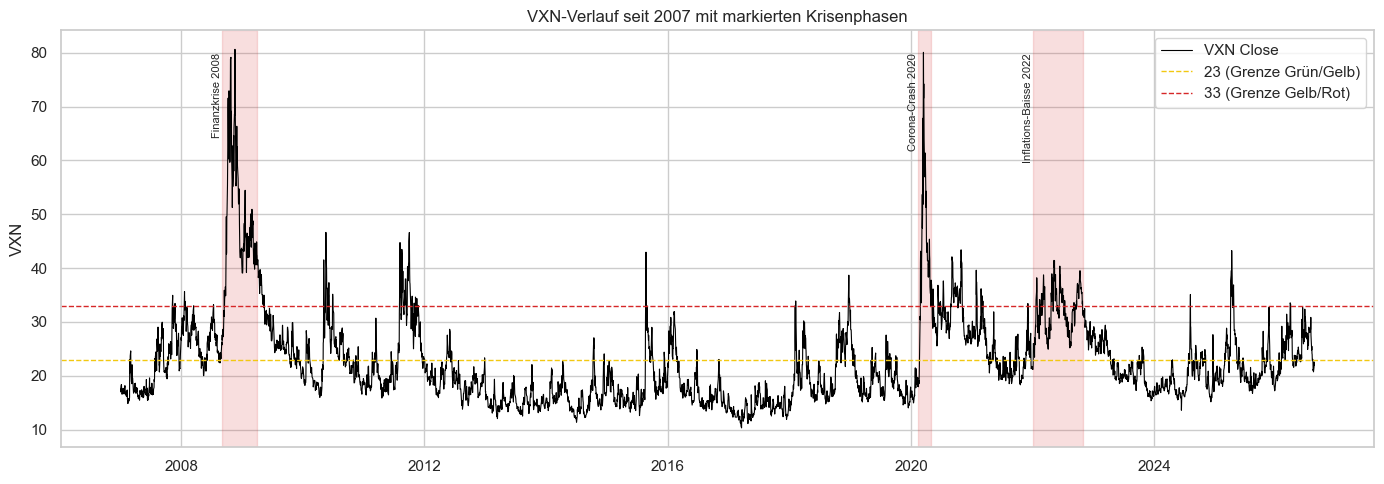

In [6]:
crisis_periods = {
    "Finanzkrise 2008": ("2008-09-01", "2009-03-31"),
    "Corona-Crash 2020": ("2020-02-15", "2020-04-30"),
    "Inflations-Baisse 2022": ("2022-01-01", "2022-10-31"),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vxn_close"], color="black", linewidth=0.8, label="VXN Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)
    ax.text(pd.Timestamp(start), ax.get_ylim()[1] * 0.95, label, fontsize=8, rotation=90,
            va="top", ha="right")

ax.axhline(VXN_THRESHOLD_GELB, color=COLOR_YELLOW, linestyle="--", linewidth=1,
           label=f"{VXN_THRESHOLD_GELB} (Grenze Grün/Gelb)")
ax.axhline(VXN_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", linewidth=1,
           label=f"{VXN_THRESHOLD_ROT} (Grenze Gelb/Rot)")
ax.set_title("VXN-Verlauf seit 2007 mit markierten Krisenphasen")
ax.set_ylabel("VXN")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


Auswertbare Tage - Baseline: 4905, >23: 1839, >33: 468
         Rend. Baseline Rend. >23 Rend. >33 MaxDD Baseline MaxDD >23 MaxDD >33
Horizont                                                                      
5T               +0.33%    +0.40%    +0.68%         -1.97%    -2.89%    -4.09%
10T              +0.65%    +0.79%    +1.02%         -3.19%    -4.49%    -6.28%
15T              +0.97%    +1.17%    +1.86%         -4.10%    -5.64%    -7.53%
30T              +1.95%    +2.58%    +4.09%         -6.09%    -7.98%    -9.87%


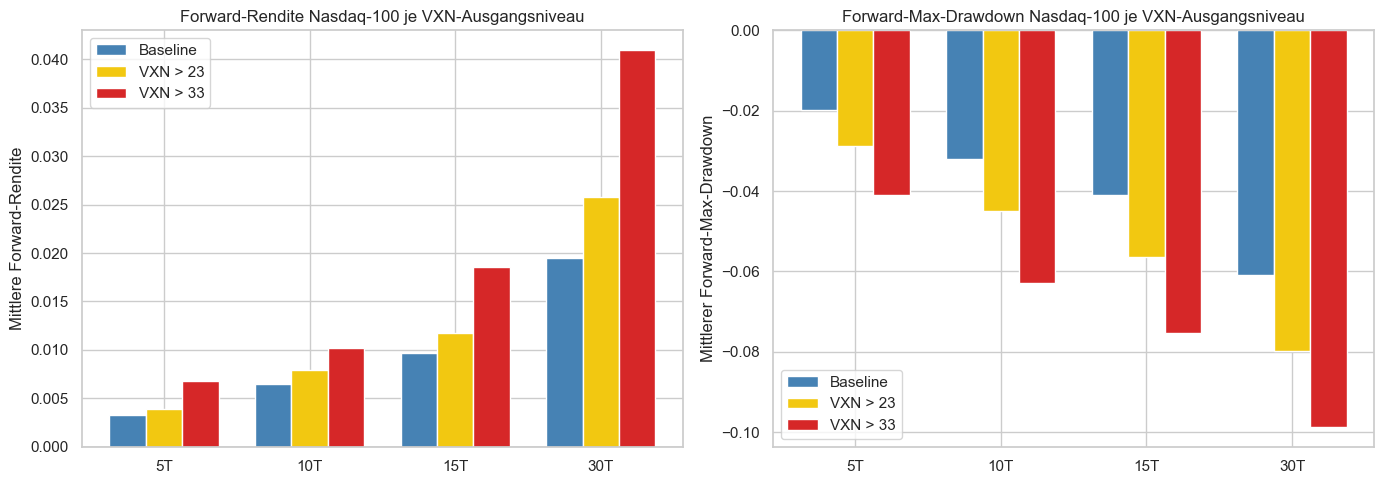

In [7]:
# Quantitative Ergänzung: Wie entwickelt sich der Nasdaq-100 nach Tagen mit erhöhtem
# VXN? Verglichen werden erhöhte Niveaus (VXN > 23 bzw. VXN > 33)
# mit der unbedingten Baseline (alle Handelstage).
maske_gelb = df["vxn_close"] > VXN_THRESHOLD_GELB
maske_rot = df["vxn_close"] > VXN_THRESHOLD_ROT

zeilen_h1 = []
for h in HORIZONS:
    fr_base, mdd_base, n_base = forward_kennzahlen(ALL_DAYS, h)
    fr_g, mdd_g, n_g = forward_kennzahlen(maske_gelb, h)
    fr_r, mdd_r, n_r = forward_kennzahlen(maske_rot, h)
    zeilen_h1.append({
        "Horizont": f"{h}T",
        "Rend. Baseline": fr_base, "Rend. >23": fr_g, "Rend. >33": fr_r,
        "MaxDD Baseline": mdd_base, "MaxDD >23": mdd_g, "MaxDD >33": mdd_r,
    })
tab_h1 = pd.DataFrame(zeilen_h1).set_index("Horizont")

disp_h1 = tab_h1.copy()
for spalte in disp_h1.columns:
    disp_h1[spalte] = tab_h1[spalte].map(lambda x: f"{x:+.2%}")
print(f"Auswertbare Tage - Baseline: {n_base}, >23: {n_g}, >33: {n_r}")
print(disp_h1.to_string())

fig, (ax_r, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(HORIZONS)); w = 0.25
ax_r.bar(x - w, tab_h1["Rend. Baseline"], w, label="Baseline", color="steelblue")
ax_r.bar(x,     tab_h1["Rend. >23"],  w, label="VXN > 23", color=COLOR_YELLOW)
ax_r.bar(x + w, tab_h1["Rend. >33"],  w, label="VXN > 33", color=COLOR_RED)
ax_r.axhline(0, color="black", linewidth=0.8)
ax_r.set_xticks(x); ax_r.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_r.set_ylabel("Mittlere Forward-Rendite")
ax_r.set_title("Forward-Rendite Nasdaq-100 je VXN-Ausgangsniveau")
ax_r.legend()

ax_d.bar(x - w, tab_h1["MaxDD Baseline"], w, label="Baseline", color="steelblue")
ax_d.bar(x,     tab_h1["MaxDD >23"],  w, label="VXN > 23", color=COLOR_YELLOW)
ax_d.bar(x + w, tab_h1["MaxDD >33"],  w, label="VXN > 33", color=COLOR_RED)
ax_d.set_xticks(x); ax_d.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
ax_d.set_title("Forward-Max-Drawdown Nasdaq-100 je VXN-Ausgangsniveau")
ax_d.legend()
plt.tight_layout(); plt.show()


**Ergebnis:** Der VXN bewegt sich den überwiegenden Teil der Zeit unterhalb
von 23 und schießt in den markierten Krisenphasen sichtbar über 33. Die
Ausgangshypothese eines ruhigen Normalzustands mit seltenen, aber massiven
Ausschlägen wird damit klar bestätigt.

**Ergänzung – Forward-Kennzahlen des Nasdaq-100:** Ein erhöhter VXN ist historisch
kein Verkaufssignal. Nach Tagen mit VXN > 33 lag die mittlere Forward-Rendite
des Nasdaq-100 über 30 Tage bei +4,09 % und damit über
der Baseline (+1,95 %). Der Weg dorthin ist jedoch riskanter: Der
mittlere Forward-Max-Drawdown vertieft sich über 30 Tage von −6,09 %
(Baseline) auf −9,87 % (VXN > 33). Der VXN misst also Risiko und
Schwankungsbreite, nicht die Richtung.

**Praxisrelevanz für das Ampelsystem:** Die Grafik liefert die Grundlegitimation,
den VXN als Kernindikator einer Nasdaq-100-Ampel zu verwenden. Die Forward-Kennzahlen
schärfen die Lesart: Rot bedeutet „erhöhtes Schwankungs- und Drawdown-Risiko",
nicht „Kurse fallen sicher" – die Ampel steuert das Risiko, nicht die
Renditeerwartung.

### 4.2 H2 – VXN vs. Nasdaq-100-Renditen

**Hypothese:** Hohe VXN-Werte bzw. -Anstiege gehen mit negativen/volatilen
Nasdaq-100-Renditen einher (inverse Beziehung). Untersucht wird der Zusammenhang
zwischen (a) der täglichen VXN-Veränderung und (b) dem VXN-Niveau jeweils
gegenüber der Nasdaq-100-Tagesrendite (Pearson-Korrelation, Streudiagramme).


Korrelation VXN-Tagesänderung vs. Nasdaq-100-Tagesrendite: -0.786
Korrelation VXN-Niveau vs. Nasdaq-100-Tagesrendite: -0.131


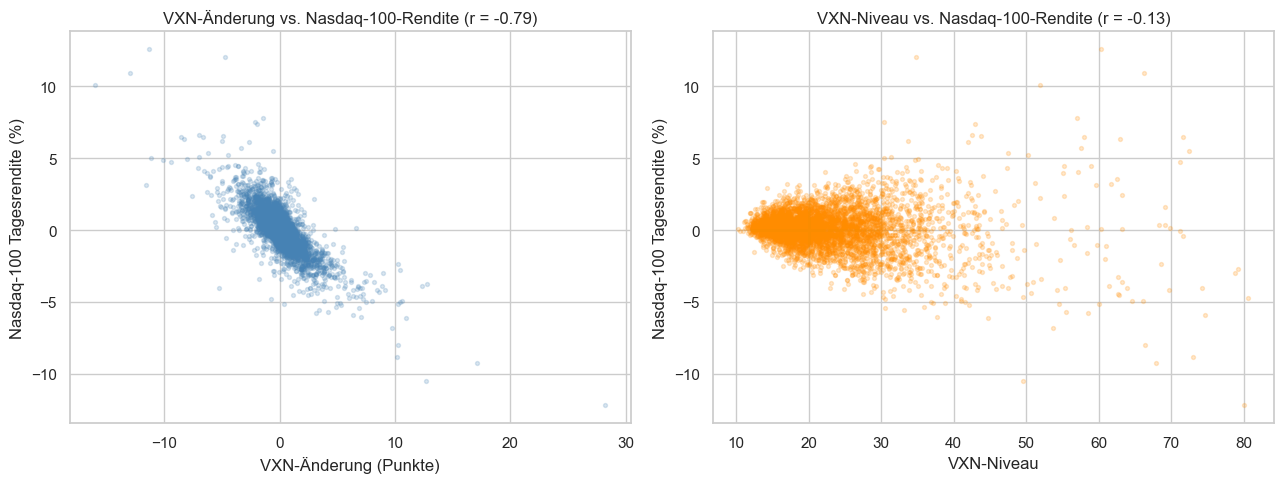

In [8]:
corr_change = df[["vxn_change", "nasdaq100_return"]].corr().iloc[0, 1]
corr_level = df[["vxn_close", "nasdaq100_return"]].corr().iloc[0, 1]
print(f"Korrelation VXN-Tagesänderung vs. Nasdaq-100-Tagesrendite: {corr_change:.3f}")
print(f"Korrelation VXN-Niveau vs. Nasdaq-100-Tagesrendite: {corr_level:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["vxn_change"], df["nasdaq100_return"], alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("VXN-Änderung (Punkte)")
axes[0].set_ylabel("Nasdaq-100 Tagesrendite (%)")
axes[0].set_title(f"VXN-Änderung vs. Nasdaq-100-Rendite (r = {corr_change:.2f})")

axes[1].scatter(df["vxn_close"], df["nasdaq100_return"], alpha=0.2, s=8, color="darkorange")
axes[1].set_xlabel("VXN-Niveau")
axes[1].set_ylabel("Nasdaq-100 Tagesrendite (%)")
axes[1].set_title(f"VXN-Niveau vs. Nasdaq-100-Rendite (r = {corr_level:.2f})")

plt.tight_layout()
plt.show()

**Ergebnis:** Die tägliche VXN-Veränderung ist stark invers mit der
Nasdaq-100-Tagesrendite korreliert (r = −0,786) – steigt der VXN
deutlich, fällt der Index am selben Tag fast immer. Das reine VXN-Niveau sagt
dagegen kaum etwas über die Tagesrendite aus (r = −0,131).

**Praxisrelevanz für das Ampelsystem:** Der VXN eignet sich als
Zustandsindikator („wie angespannt ist der Markt"), nicht als Renditeprognose.
Rot heißt „erhöhte Vorsicht", nicht „der Markt fällt heute".

### 4.3 H3 – Volatility Clustering (Autokorrelation)

**Hypothese:** Der VXN zeigt Volatility Clustering, d. h. hohe bzw. niedrige
Werte treten in Clustern auf statt zufällig zu springen. Gemessen wird die
Autokorrelation des VXN-Niveaus für Lags von 1 bis 20 Handelstagen – relevant
für die Stabilität einer täglichen Ampel.


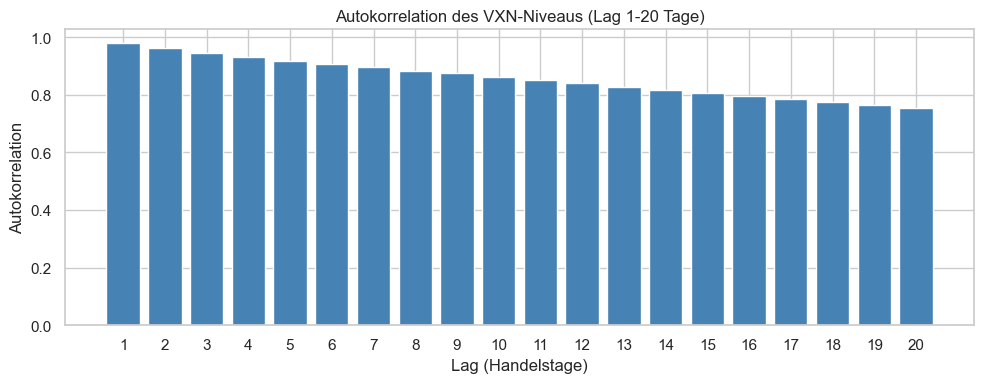

Autokorrelation Lag 1 (Vortag): 0.978
Autokorrelation Lag 5 (Vorwoche): 0.918


In [9]:
from pandas.plotting import autocorrelation_plot

lags = range(1, 21)
autocorrs = [df["vxn_close"].autocorr(lag) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, autocorrs, color="steelblue")
ax.set_xlabel("Lag (Handelstage)")
ax.set_ylabel("Autokorrelation")
ax.set_title("Autokorrelation des VXN-Niveaus (Lag 1-20 Tage)")
ax.set_xticks(list(lags))
plt.tight_layout()
plt.show()

print(f"Autokorrelation Lag 1 (Vortag): {df['vxn_close'].autocorr(1):.3f}")
print(f"Autokorrelation Lag 5 (Vorwoche): {df['vxn_close'].autocorr(5):.3f}")

**Ergebnis:** Die Autokorrelation des VXN ist sowohl auf Tages-
(Lag 1: 0,978) als auch auf Wochensicht (Lag 5: 0,918)
extrem hoch. Der VXN ist damit ausgeprägt träge: ein hoher Wert heute macht
einen hohen Wert morgen sehr wahrscheinlich.

**Praxisrelevanz für das Ampelsystem:** Diese Trägheit ist für eine tägliche
Ampel ein Vorteil – die Farbe „flackert" nicht, sondern entwickelt sich stabil
über mehrere Tage. Das erhöht Glaubwürdigkeit und Akzeptanz des Signals.

### 4.4 H4 – Verteilung des VXN und Ampel-Schwellenwerte

**Hypothese:** Anhand der historischen Verteilung (Quantile) lassen sich
plausible Schwellenwerte für Grün/Gelb/Rot ableiten. Da der VXN ein anderes
typisches Niveau als der VIX hat, werden die Schwellen **nicht** von den
VIX-Faustregeln 20/30 übernommen, sondern so aus der VXN-Verteilung bestimmt,
dass sich vergleichbare Ampel-Anteile wie beim VIX (rund 64 % Grün / 27 % Gelb /
9 % Rot) ergeben. Geprüft wird, welcher Anteil der Handelstage in welche
Ampelphase fällt.


VXN-Quantile:
0.50    20.46
0.70    24.96
0.75    26.41
0.80    27.86
0.90    32.68
0.95    37.60
0.99    56.46
Name: vxn_close, dtype: float64


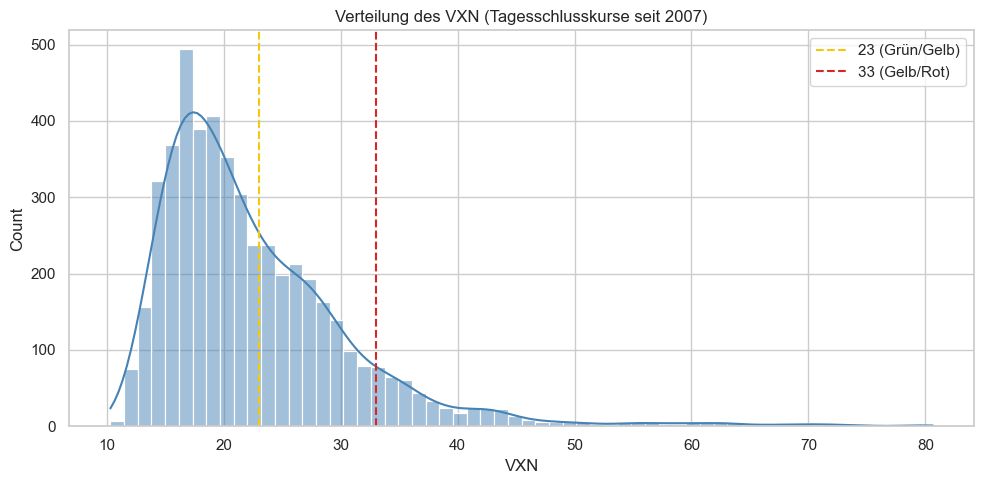

Grün (<23): 62.3% der Handelstage
Gelb (23-33): 28.2% der Handelstage
Rot (>33): 9.5% der Handelstage


In [10]:
quantiles = df["vxn_close"].quantile([0.5, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99])
print("VXN-Quantile:")
print(quantiles.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["vxn_close"], bins=60, kde=True, ax=ax, color="steelblue")
ax.axvline(VXN_THRESHOLD_GELB, color=COLOR_YELLOW, linestyle="--", label=f"{VXN_THRESHOLD_GELB} (Grün/Gelb)")
ax.axvline(VXN_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", label=f"{VXN_THRESHOLD_ROT} (Gelb/Rot)")
ax.set_title("Verteilung des VXN (Tagesschlusskurse seit 2007)")
ax.set_xlabel("VXN")
ax.legend()
plt.tight_layout()
plt.show()

grenzen = [(0, VXN_THRESHOLD_GELB, f"Grün (<{VXN_THRESHOLD_GELB})"),
           (VXN_THRESHOLD_GELB, VXN_THRESHOLD_ROT, f"Gelb ({VXN_THRESHOLD_GELB}-{VXN_THRESHOLD_ROT})"),
           (VXN_THRESHOLD_ROT, np.inf, f"Rot (>{VXN_THRESHOLD_ROT})")]
for low, high, label in grenzen:
    share = ((df["vxn_close"] >= low) & (df["vxn_close"] < high)).mean() * 100
    print(f"{label}: {share:.1f}% der Handelstage")


**Ergebnis:** Die VXN-Verteilung ist rechtsschief (Median 20,5
unter Mittelwert 22,7). Die datenbasiert gewählten Schwellen
**23** und **33** teilen die Handelstage in 62,2 % Grün,
28,3 % Gelb und 9,5 % Rot – nahezu die gleichen Anteile wie
beim VIX (64 % / 27 % / 9 %) mit seinen Faustregeln 20/30. Die Perzentile
(50/75/90/95 = 20,5 / 26,4 / 32,7 /
37,6) stützen die Wahl: Die Grün/Gelb-Grenze 23 liegt nahe dem
75. Perzentil, die Rot-Grenze 33 nahe dem 90. Perzentil.

**Praxisrelevanz für das Ampelsystem:** Weil der VXN ein anderes Kursniveau
als der VIX hat, wären die VIX-Werte 20/30 hier ungeeignet gewesen. Die
datenbasierte Herleitung liefert VXN-eigene Schwellen mit vergleichbarer
Alarmhäufigkeit: Der Rot-Anteil von 9,5 % zeigt, wie oft die Routine
Alarm schlagen würde – selten genug, um „Alarm-Fatigue" zu vermeiden.

### 4.5 H5 – Dauer der Ampelphasen

**Hypothese:** Mit den datenbasierten Schwellen 23/33 wird jeder
Handelstag in Grün/Gelb/Rot klassifiziert; anschließend werden zusammenhängende
Phasen identifiziert und ihre Dauer ausgewertet – wichtig, um einzuschätzen, ob
die Ampel stabil genug für eine tägliche Routine ist.


In [11]:
def ampel(vxn_value: float) -> str:
    if vxn_value < VXN_THRESHOLD_GELB:
        return "grün"
    elif vxn_value < VXN_THRESHOLD_ROT:
        return "gelb"
    return "rot"

df["ampel"] = df["vxn_close"].apply(ampel)

phase_id = (df["ampel"] != df["ampel"].shift()).cumsum().rename("phase_id")
phases = df.groupby(phase_id).agg(
    ampel=("ampel", "first"),
    start=("ampel", lambda s: s.index[0]),
    ende=("ampel", lambda s: s.index[-1]),
    dauer_tage=("ampel", "size"),
)

print("Anzahl Phasenwechsel gesamt:", len(phases))
print("\nDurchschnittliche Phasendauer (Handelstage) je Ampelfarbe:")
print(phases.groupby("ampel")["dauer_tage"].describe()[["count", "mean", "50%", "max"]])

print("\nDie 5 längsten Rot-Phasen:")
print(phases[phases["ampel"] == "rot"].sort_values("dauer_tage", ascending=False).head())


Anzahl Phasenwechsel gesamt: 350

Durchschnittliche Phasendauer (Handelstage) je Ampelfarbe:
       count       mean  50%    max
ampel                              
gelb   174.0   8.000000  3.0  114.0
grün   117.0  26.273504  5.0  449.0
rot     59.0   7.949153  2.0  163.0

Die 5 längsten Rot-Phasen:
         ampel      start       ende  dauer_tage
phase_id                                        
43         rot 2008-09-19 2009-05-13         163
192        rot 2020-02-27 2020-04-28          43
208        rot 2020-08-31 2020-10-08          28
274        rot 2022-09-23 2022-10-27          25
210        rot 2020-10-12 2020-11-04          18


**Ergebnis:** Über den Zeitraum gab es 349 Phasenwechsel.
Rot-Phasen sind meist kurz (Median 2 Handelstage), können in
echten Krisen aber lange dauern (längste Phase 163 Tage). Mittelwert
(7,9) und Median (2) klaffen stark
auseinander – Rot ist meist ein kurzer Warnblinker, selten ein Dauerzustand.

**Praxisrelevanz für das Ampelsystem:** Ein einzelner Rot-Tag sollte keine
drastische Reaktion auslösen, da er statistisch meist nach wenigen Tagen abklingt.
Eine Eskalationsregel („Rot an 3+ Tagen in Folge = erhöhte Warnstufe") trennt
kurzfristiges Rauschen von echten Krisenphasen.

### 4.6 H6 – Neues 3-Monats-Hoch als Frühwarnsignal

**Hypothese:** Wenn der VXN ein neues 3-Monats-Hoch erreicht (höchster
Schlusskurs der vorangegangenen ca. 63 Handelstage), folgt in den nächsten
5 bzw. 10 Handelstagen überdurchschnittlich oft eine Phase mit VXN > 33.
Die Trefferquote wird mit der unbedingten Baseline verglichen.


In [12]:
# Rollierendes 3-Monats-Hoch VOR dem aktuellen Tag berechnen. shift(1) stellt sicher,
# dass der aktuelle Tag selbst nicht im Vergleichsfenster enthalten ist (kein Blick in die Zukunft).
WINDOW_3M = 63
rolling_high_3m = df["vxn_close"].shift(1).rolling(WINDOW_3M).max()

# Signaltage: aktueller Schlusskurs liegt über dem rollierenden 3-Monats-Hoch
new_3m_high = df["vxn_close"] > rolling_high_3m
print(f"Anzahl Signaltage (neues 3-Monats-Hoch): {int(new_3m_high.sum())}")

hit_rate_5 = forward_hit_rate(new_3m_high, horizon=5)
hit_rate_10 = forward_hit_rate(new_3m_high, horizon=10)
baseline_5 = forward_hit_rate(ALL_DAYS, horizon=5)
baseline_10 = forward_hit_rate(ALL_DAYS, horizon=10)

print(f"Trefferquote nach Signal, 5 Tage:  {hit_rate_5:.1%}  (Baseline: {baseline_5:.1%})")
print(f"Trefferquote nach Signal, 10 Tage: {hit_rate_10:.1%}  (Baseline: {baseline_10:.1%})")

Anzahl Signaltage (neues 3-Monats-Hoch): 180
Trefferquote nach Signal, 5 Tage:  37.2%  (Baseline: 13.1%)
Trefferquote nach Signal, 10 Tage: 42.2%  (Baseline: 15.9%)


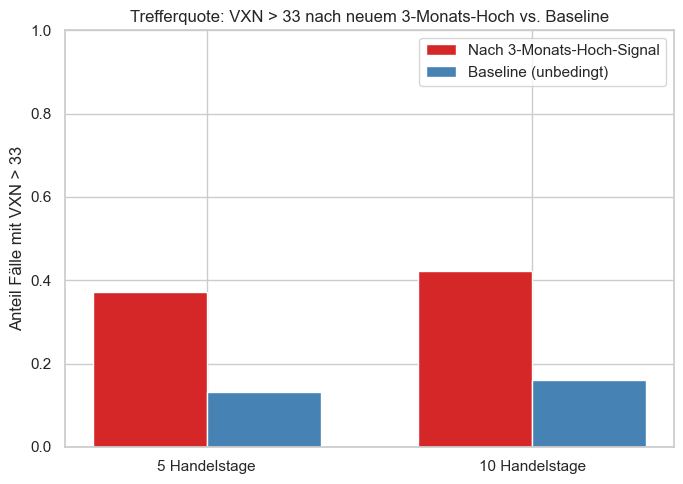

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["5 Handelstage", "10 Handelstage"]
signal_rates = [hit_rate_5, hit_rate_10]
baseline_rates = [baseline_5, baseline_10]
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width / 2, signal_rates, width, label="Nach 3-Monats-Hoch-Signal", color=COLOR_RED)
ax.bar(x + width / 2, baseline_rates, width, label="Baseline (unbedingt)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(f"Anteil Fälle mit VXN > {VXN_THRESHOLD_ROT}")
ax.set_ylim(0, 1)
ax.set_title("Trefferquote: VXN > 33 nach neuem 3-Monats-Hoch vs. Baseline")
ax.legend()
plt.tight_layout()
plt.show()

Signaltage (neues 3-Monats-Hoch): 180
         Trefferq. Signal Trefferq. Baseline Rend. Signal Rend. Baseline MaxDD Signal MaxDD Baseline
Horizont                                                                                            
5T                  37.2%              13.1%       +0.89%         +0.33%       -3.26%         -1.97%
10T                 42.2%              15.9%       +0.85%         +0.65%       -5.18%         -3.19%
15T                 43.3%              18.1%       +1.42%         +0.97%       -6.32%         -4.10%
30T                 44.4%              24.0%       +3.15%         +1.95%       -7.98%         -6.09%


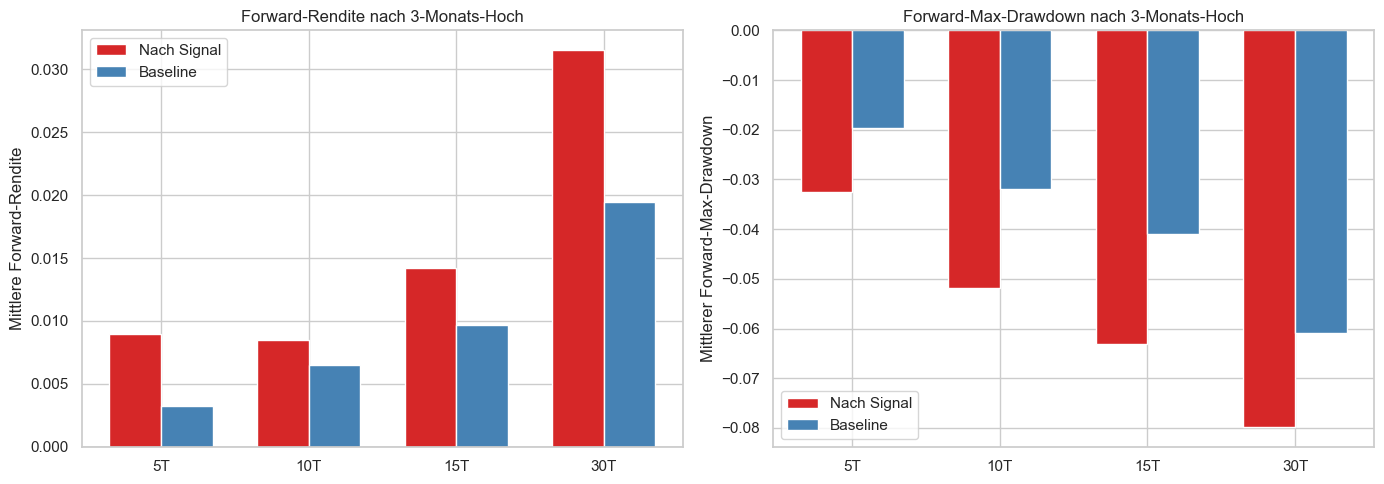

In [14]:
# Ergänzung: Forward-Rendite und Forward-Max-Drawdown des Nasdaq-100 nach dem
# 3-Monats-Hoch-Signal, plus Erweiterung der Trefferquote auf alle Horizonte.
zeilen_h6 = []
for h in HORIZONS:
    hr_sig = forward_hit_rate(new_3m_high, horizon=h)
    hr_base = forward_hit_rate(ALL_DAYS, horizon=h)
    fr_sig, mdd_sig, n_sig = forward_kennzahlen(new_3m_high, h)
    fr_base, mdd_base, _ = forward_kennzahlen(ALL_DAYS, h)
    zeilen_h6.append({
        "Horizont": f"{h}T",
        "Trefferq. Signal": hr_sig, "Trefferq. Baseline": hr_base,
        "Rend. Signal": fr_sig, "Rend. Baseline": fr_base,
        "MaxDD Signal": mdd_sig, "MaxDD Baseline": mdd_base,
    })
tab_h6 = pd.DataFrame(zeilen_h6).set_index("Horizont")

disp_h6 = tab_h6.copy()
for spalte in ["Trefferq. Signal", "Trefferq. Baseline"]:
    disp_h6[spalte] = tab_h6[spalte].map(lambda x: f"{x:.1%}")
for spalte in ["Rend. Signal", "Rend. Baseline", "MaxDD Signal", "MaxDD Baseline"]:
    disp_h6[spalte] = tab_h6[spalte].map(lambda x: f"{x:+.2%}")
print(f"Signaltage (neues 3-Monats-Hoch): {int(new_3m_high.sum())}")
print(disp_h6.to_string())

fig, (ax_r, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(HORIZONS)); w = 0.35
ax_r.bar(x - w/2, tab_h6["Rend. Signal"], w, label="Nach Signal", color=COLOR_RED)
ax_r.bar(x + w/2, tab_h6["Rend. Baseline"], w, label="Baseline", color="steelblue")
ax_r.axhline(0, color="black", linewidth=0.8)
ax_r.set_xticks(x); ax_r.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_r.set_ylabel("Mittlere Forward-Rendite")
ax_r.set_title("Forward-Rendite nach 3-Monats-Hoch")
ax_r.legend()
ax_d.bar(x - w/2, tab_h6["MaxDD Signal"], w, label="Nach Signal", color=COLOR_RED)
ax_d.bar(x + w/2, tab_h6["MaxDD Baseline"], w, label="Baseline", color="steelblue")
ax_d.set_xticks(x); ax_d.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
ax_d.set_title("Forward-Max-Drawdown nach 3-Monats-Hoch")
ax_d.legend()
plt.tight_layout(); plt.show()


**Ergebnis:** Über den Beobachtungszeitraum gab es 180 neue
3-Monats-Hochs. Nach einem solchen Signal lag der VXN in 37,2 %
(5 Tage) bzw. 42,2 % (10 Tage) der Fälle mindestens einmal über
33 – gegenüber einer Baseline von 13,1 % / 15,9 %.
Über die längeren Horizonte bleibt der Abstand bestehen (15/30 Tage:
43,3 % / 44,4 % gegenüber 18,2 % /
24,0 %). Das Signal erhöht die Trefferquote also robust, bleibt
aber ein Minderheits-Ereignis.

**Ergänzung – Forward-Kennzahlen des Nasdaq-100:** Wie in 4.1 markiert das Signal
erhöhtes Risiko, keine fallenden Kurse. Die mittlere Forward-Rendite nach dem
3-Monats-Hoch liegt über 30 Tage bei +3,15 % (über
Baseline +1,95 %), der Forward-Max-Drawdown fällt jedoch tiefer aus
(30 Tage: −7,98 % gegenüber −6,09 %). Das neue
3-Monats-Hoch kündigt somit vor allem eine turbulentere, im Mittel aber positiv
driftende Phase an.

**Praxisrelevanz für das Ampelsystem:** Ein neues 3-Monats-Hoch eignet sich als
zusätzliches „Vorsicht"-Flag, das bereits vor Erreichen der Rot-Schwelle
anschlägt – als kleines Warnsymbol neben der Hauptampel. Es warnt vor erhöhter
Schwankung und tieferen Rücksetzern, nicht vor einem Renditeeinbruch.

### 4.7 H7 – „3-Punkte-Umkehr“ als Beruhigungssignal

**Hypothese:** An Tagen mit Open ≥ 23 UND Intraday-High > Open UND
(Intraday-High − Close) ≥ 3 schießt der VXN im Tagesverlauf nach oben, gibt
den Anstieg bis Handelsschluss aber größtenteils wieder ab. Geprüft wird per
Event-Study, ob der VXN an den 5 Folgetagen im Schnitt fällt (= Beruhigung).


In [15]:
# Signal-Definition: ausgeprägte Intraday-Umkehr im VXN
#   - Open >= 23          -> Markt startet bereits angespannt (Gelb-Niveau)
#   - High > Open             -> im Tagesverlauf zieht der VXN weiter an
#   - (High - Close) >= 3     -> der Tag schließt aber mindestens 3 Punkte unter dem Hoch
vxn_ohlc = vxn[["Open", "High", "Low", "Close"]].reindex(df.index)

reversal_signal = (
    (vxn_ohlc["Open"] >= VXN_THRESHOLD_GELB)
    & (vxn_ohlc["High"] > vxn_ohlc["Open"])
    & ((vxn_ohlc["High"] - vxn_ohlc["Close"]) >= 3)
)
signal_dates = df.index[reversal_signal.values]
print(f"Anzahl '3-Punkte-Umkehr'-Signale: {len(signal_dates)}")

HORIZON_H2 = 5
vxn_close_values = df["vxn_close"]
paths = []
for date in signal_dates:
    pos = df.index.get_loc(date)
    if pos + HORIZON_H2 >= len(df):
        continue
    base = vxn_close_values.iloc[pos]
    path = vxn_close_values.iloc[pos : pos + HORIZON_H2 + 1].values - base
    paths.append(path)
paths = np.array(paths)

mean_path = paths.mean(axis=0)
median_path = np.median(paths, axis=0)
share_falling = (paths[:, -1] < 0).mean()

print(f"Auswertbare Signale: {len(paths)}")
print(f"Durchschnittliche VXN-Änderung nach {HORIZON_H2} Tagen: {mean_path[-1]:+.2f} Punkte")
print(f"Median VXN-Änderung nach {HORIZON_H2} Tagen:            {median_path[-1]:+.2f} Punkte")
print(f"Anteil Fälle mit niedrigerem VXN nach {HORIZON_H2} Tagen: {share_falling:.1%}")


Anzahl '3-Punkte-Umkehr'-Signale: 193
Auswertbare Signale: 193
Durchschnittliche VXN-Änderung nach 5 Tagen: -1.17 Punkte
Median VXN-Änderung nach 5 Tagen:            -1.79 Punkte
Anteil Fälle mit niedrigerem VXN nach 5 Tagen: 65.8%


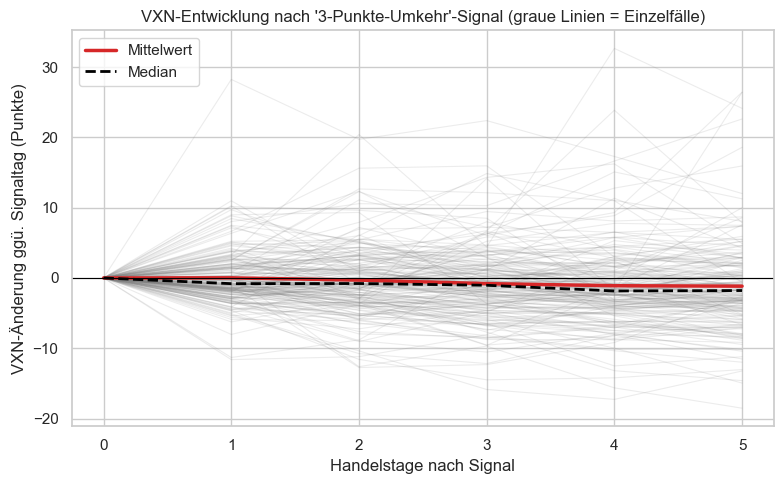

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
days = np.arange(0, HORIZON_H2 + 1)
for path in paths:
    ax.plot(days, path, color="grey", alpha=0.15, linewidth=0.8)
ax.plot(days, mean_path, color=COLOR_RED, linewidth=2.5, label="Mittelwert")
ax.plot(days, median_path, color="black", linewidth=2, linestyle="--", label="Median")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Handelstage nach Signal")
ax.set_ylabel("VXN-Änderung ggü. Signaltag (Punkte)")
ax.set_title("VXN-Entwicklung nach '3-Punkte-Umkehr'-Signal (graue Linien = Einzelfälle)")
ax.legend()
plt.tight_layout()
plt.show()

Auswertbare Signaltage: 193
         Rend. Signal Rend. Baseline MaxDD Signal MaxDD Baseline
Horizont                                                        
5T             +0.34%         +0.33%       -3.67%         -1.97%
10T            +0.45%         +0.65%       -5.56%         -3.19%
15T            +0.79%         +0.97%       -6.85%         -4.10%
30T            +1.74%         +1.95%       -9.73%         -6.09%


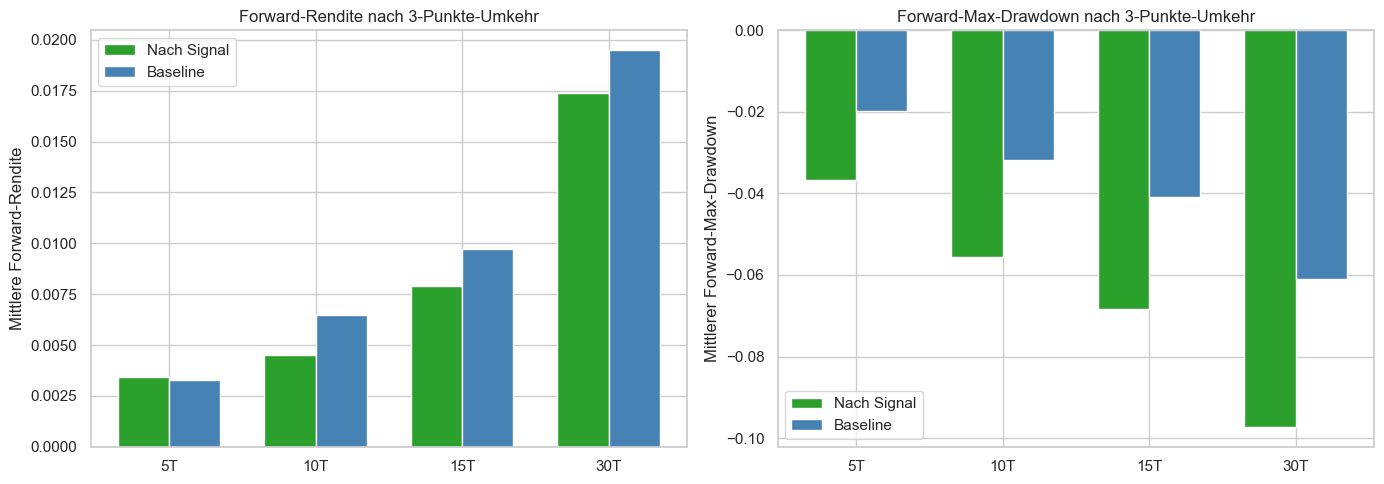

In [17]:
# Ergänzung: Das Umkehr-Signal wird zusätzlich als Renditesignalgeber für den
# Nasdaq-100 ausgewertet (Forward-Rendite und Forward-Max-Drawdown), im Vergleich
# zur Baseline. Die VXN-eigene Beruhigungs-Auswertung oben bleibt bestehen.
zeilen_h7 = []
for h in HORIZONS:
    fr_sig, mdd_sig, n_sig = forward_kennzahlen(reversal_signal, h)
    fr_base, mdd_base, _ = forward_kennzahlen(ALL_DAYS, h)
    zeilen_h7.append({
        "Horizont": f"{h}T",
        "Rend. Signal": fr_sig, "Rend. Baseline": fr_base,
        "MaxDD Signal": mdd_sig, "MaxDD Baseline": mdd_base,
    })
tab_h7 = pd.DataFrame(zeilen_h7).set_index("Horizont")

disp_h7 = tab_h7.copy()
for spalte in disp_h7.columns:
    disp_h7[spalte] = tab_h7[spalte].map(lambda x: f"{x:+.2%}")
print(f"Auswertbare Signaltage: {n_sig}")
print(disp_h7.to_string())

fig, (ax_r, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(HORIZONS)); w = 0.35
ax_r.bar(x - w/2, tab_h7["Rend. Signal"], w, label="Nach Signal", color=COLOR_GREEN)
ax_r.bar(x + w/2, tab_h7["Rend. Baseline"], w, label="Baseline", color="steelblue")
ax_r.axhline(0, color="black", linewidth=0.8)
ax_r.set_xticks(x); ax_r.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_r.set_ylabel("Mittlere Forward-Rendite")
ax_r.set_title("Forward-Rendite nach 3-Punkte-Umkehr")
ax_r.legend()
ax_d.bar(x - w/2, tab_h7["MaxDD Signal"], w, label="Nach Signal", color=COLOR_GREEN)
ax_d.bar(x + w/2, tab_h7["MaxDD Baseline"], w, label="Baseline", color="steelblue")
ax_d.set_xticks(x); ax_d.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
ax_d.set_title("Forward-Max-Drawdown nach 3-Punkte-Umkehr")
ax_d.legend()
plt.tight_layout(); plt.show()


**Ergebnis:** Von 193 „3-Punkte-Umkehr"-Signalen fiel der VXN
in 65,8 % der Fälle innerhalb von 5 Handelstagen unter den
Stand des Signaltags, im Schnitt um −1,17 Punkte (Median
−1,79). Die Beruhigungs-Hypothese wird tendenziell bestätigt
(rund zwei von drei Fällen), ist aber kein Automatismus.

**Ergänzung – der Nasdaq-100 als Renditesignal:** Wertet man das Signal als
Renditesignalgeber für den Index aus, liegt die Forward-Rendite über 30 Tage bei
+1,74 % und damit leicht unter der Baseline (+1,95 %).
Der Pfad bleibt schwankungsanfällig – der Forward-Max-Drawdown ist mit
−9,71 % tiefer als die Baseline (−6,09 %). Die
VXN-Beruhigung ersetzt also kein aktives Risikomanagement.

**Praxisrelevanz für das Ampelsystem:** Das Signal eignet sich als
Entwarnungs-Hinweis innerhalb einer Gelb-/Rot-Phase („mögliche nahende
Beruhigung, historisch ca. 2 von 3 Fällen"), ohne einen neuen Ampelzustand zu
erzeugen.

### 4.8 H8 – VXN-Schwellenwerte anhand Verteilung und Stressphasen

**Hypothese:** Der VXN hebt sich während bekannter Stressphasen ab einem
bestimmten Niveau sichtbar vom Normalzustand ab. Verglichen werden die
Perzentile der Gesamtverteilung (50/75/90/95) mit Median, Minimum und Maximum
des VXN innerhalb und außerhalb der Krisenphasen, um die Gelb-/Rot-Schwellen
datenbasiert zu validieren.


In [18]:
percentiles_h3 = df["vxn_close"].quantile([0.50, 0.75, 0.90, 0.95])
print("VXN-Perzentile (gesamter Zeitraum):")
print(percentiles_h3.round(2))

# Boolesche Maske: Tag liegt innerhalb einer der definierten Stressphasen
in_crisis = pd.Series(False, index=df.index)
for start, end in crisis_periods.values():
    in_crisis |= (df.index >= start) & (df.index <= end)

print("\nVXN während Stressphasen (Median / Min / Max):")
print(df.loc[in_crisis, "vxn_close"].agg(["median", "min", "max"]).round(2))
print("\nVXN außerhalb von Stressphasen (Median / Min / Max):")
print(df.loc[~in_crisis, "vxn_close"].agg(["median", "min", "max"]).round(2))

VXN-Perzentile (gesamter Zeitraum):
0.50    20.46
0.75    26.41
0.90    32.68
0.95    37.60
Name: vxn_close, dtype: float64

VXN während Stressphasen (Median / Min / Max):
median    36.40
min       18.58
max       80.64
Name: vxn_close, dtype: float64

VXN außerhalb von Stressphasen (Median / Min / Max):
median    19.80
min       10.31
max       46.63
Name: vxn_close, dtype: float64


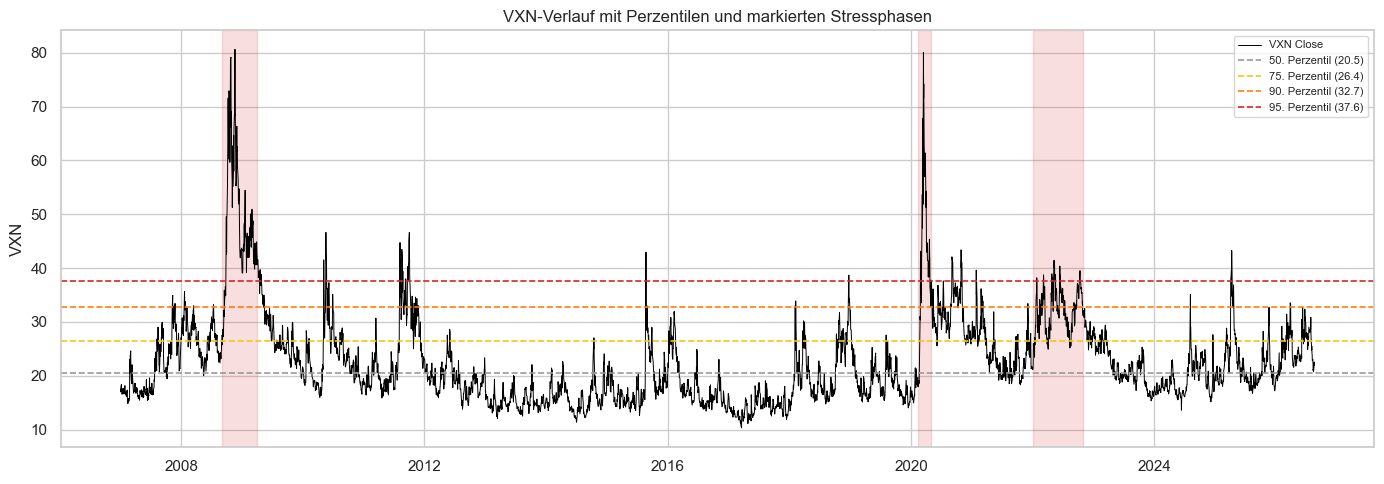

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vxn_close"], color="black", linewidth=0.7, label="VXN Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)

percentile_colors = ["#999999", COLOR_YELLOW, "#ff7f0e", COLOR_RED]
for (q, val), color in zip(percentiles_h3.items(), percentile_colors):
    ax.axhline(val, linestyle="--", linewidth=1.2, color=color,
               label=f"{int(q * 100)}. Perzentil ({val:.1f})")

ax.set_title("VXN-Verlauf mit Perzentilen und markierten Stressphasen")
ax.set_ylabel("VXN")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Ergebnis:** Der Median-VXN während der markierten Stressphasen
(36,4) liegt nahe am 90. Perzentil der Gesamtverteilung
(32,7) und deutlich über dem 75. Perzentil (26,4). Die
Rot-Schwelle 33 ist damit datenbasiert gut gedeckt, Gelb verortet sich im
Bereich 75.–90. Perzentil (ca. 26–33).
Dass der Maximalwert außerhalb der Phasen (46,6) hoch ist,
zeigt zugleich, dass die grob nach Kalenderdatum definierten Fenster nicht
trennscharf sind.

**Praxisrelevanz für das Ampelsystem:** Dieser Abschnitt belegt datenbasiert,
dass die VXN-Schwellen (Grün < 23, Gelb 23–33, Rot > 33) nicht
willkürlich sind, sondern sich an historischen Perzentilen und realem
Krisenverhalten orientieren.

### 4.9 H9 – Divergenz zum Index als Frühindikator

**Hypothese:** VXN und Nasdaq-100 sind normalerweise invers korreliert (vgl. 4.2).
Ein hoher Anteil an Tagen mit untypischem Gleichlauf (beide steigen gleichzeitig)
in einem rollierenden Fenster könnte nachfolgende Marktturbulenzen ankündigen.
Als Turbulenz-Definition dient konsistent zu 4.6: VXN > 33 in den nächsten
10 Handelstagen.


In [20]:
# Tage, an denen Nasdaq-100 UND VXN am selben Tag gleichzeitig gestiegen sind
co_up = (df["nasdaq100_return"] > 0) & (df["vxn_change"] > 0)

share_5d = co_up.rolling(5).mean()
share_10d = co_up.rolling(10).mean()

DIVERGENCE_THRESHOLD = 0.6
high_divergence_5d = share_5d > DIVERGENCE_THRESHOLD

print(f"Tage mit >{DIVERGENCE_THRESHOLD:.0%} Gleichlauf im 5-Tage-Fenster: "
      f"{int(high_divergence_5d.sum())} von {int(share_5d.notna().sum())} "
      f"({high_divergence_5d.mean():.1%})")

# Turbulenz-Wahrscheinlichkeit nach Divergenz-Signal vs. Baseline (baseline_10 aus Abschnitt 9.1,
# identische Definition: VXN > 33 in den nächsten 10 Handelstagen)
turbulence_after_divergence = forward_hit_rate(high_divergence_5d, horizon=10)

print(f"P(VXN > {VXN_THRESHOLD_ROT} in den nächsten 10 Tagen | Divergenz > {DIVERGENCE_THRESHOLD:.0%}): "
      f"{turbulence_after_divergence:.1%}")
print(f"P(VXN > {VXN_THRESHOLD_ROT} in den nächsten 10 Tagen), Baseline: {baseline_10:.1%}")

Tage mit >60% Gleichlauf im 5-Tage-Fenster: 12 von 4931 (0.2%)
P(VXN > 33 in den nächsten 10 Tagen | Divergenz > 60%): 0.0%
P(VXN > 33 in den nächsten 10 Tagen), Baseline: 15.9%


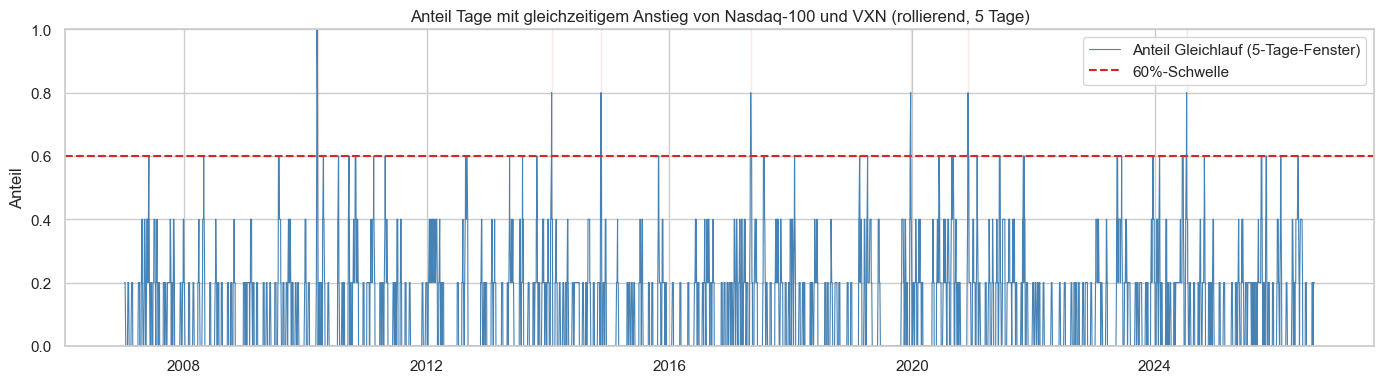

In [21]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, share_5d, color="steelblue", linewidth=0.8, label="Anteil Gleichlauf (5-Tage-Fenster)")
ax.axhline(DIVERGENCE_THRESHOLD, color=COLOR_RED, linestyle="--", label=f"{DIVERGENCE_THRESHOLD:.0%}-Schwelle")
ax.fill_between(df.index, 0, 1, where=high_divergence_5d.fillna(False).values, color=COLOR_RED, alpha=0.1)
ax.set_ylim(0, 1)
ax.set_title("Anteil Tage mit gleichzeitigem Anstieg von Nasdaq-100 und VXN (rollierend, 5 Tage)")
ax.set_ylabel("Anteil")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Ergebnis:** Ein gleichzeitiger Anstieg von Nasdaq-100 und VXN an mindestens
60 % der Tage eines 5-Tage-Fensters ist mit 12 von 4927
Fenstern extrem selten. In dieser strengen Form ist die Stichprobe statistisch
nicht belastbar (Trefferquote 0,0 % vs. Baseline 15,9 %).

**Praxisrelevanz für das Ampelsystem:** Vor einer Aufnahme in die Ampel muss die
Definition gelockert und mit mehr Fällen getestet werden – genau das leistet die
folgende systematische Rasteranalyse.

**Fortsetzung – systematischer Parameterraster:** Die Original-Definition
(5-Tage-Fenster, 60 %-Schwelle) liefert nur wenige Signale und ist statistisch
nicht belastbar. Daher wird der Divergenz-Ansatz über einen vollständig
gekreuzten Parameterraster geprüft und zugleich um die beiden Nasdaq-100-Kennzahlen
**Forward-Rendite** und **Forward-Max-Drawdown** ergänzt:

- **Vorhersagehorizont:** 10, 15, 30 Handelstage
- **Beobachtungsfenster** (rollierender Divergenz-Anteil): 10, 15, 30 Tage
- **Anteils-Schwelle** (ab wann ein Fenster als Signal zählt): 15 %, 20 %, 25 %
- **Anstiegstag:** Nasdaq-100-Tagesrendite ≥ 0,25 % **und** gleichzeitig steigender
  VXN. Die Schwelle 0,25 % liegt bewusst knapp oberhalb des Rauschens der
  Tagesrendite und bezieht sich auf den **Index**, nicht auf die VXN-Veränderung.

Das ergibt 3 × 3 × 3 = **27 Kombinationen**. Als Mindestkriterium für eine
belastbare Aussage (und damit für eine eigene Visualisierung) gelten
**mindestens 30 Signaltage**. Alle 27 Kombinationen erscheinen vollständig in
der Ergebnistabelle; separat visualisiert werden nur die belastbaren.


In [22]:
# Anstiegstag = Index-Tagesrendite >= 0,25 % UND gleichzeitig steigender VXN.
# (nasdaq100_return liegt in %, daher Schwelle 0.25; die Signifikanzschwelle bezieht
#  sich damit korrekt auf den Index und nicht auf die VXN-Veränderung.)
co_up_div = (df["nasdaq100_return"] >= 0.25) & (df["vxn_change"] > 0)

RASTER_HORIZONTE = [10, 15, 30]
RASTER_FENSTER = [10, 15, 30]
RASTER_LEVELS = [0.15, 0.20, 0.25]
MIN_SIGNALE = 30  # Mindestkriterium für Belastbarkeit und eigene Visualisierung

raster_zeilen = []
for fenster in RASTER_FENSTER:
    for level in RASTER_LEVELS:
        signal = co_up_div.rolling(fenster).mean() > level
        n_signale = int(signal.sum())
        for horizont in RASTER_HORIZONTE:
            hr = forward_hit_rate(signal, horizon=horizont)
            hr_base = forward_hit_rate(ALL_DAYS, horizon=horizont)
            fr, mdd, _ = forward_kennzahlen(signal, horizont)
            fr_base, mdd_base, _ = forward_kennzahlen(ALL_DAYS, horizont)
            raster_zeilen.append({
                "Fenster": fenster, "Schwelle": level, "Horizont": horizont,
                "Signale": n_signale,
                "Trefferquote": hr, "Trefferq_Baseline": hr_base,
                "Fwd_Rendite": fr, "Rendite_Baseline": fr_base,
                "Fwd_MaxDD": mdd, "MaxDD_Baseline": mdd_base,
                "belastbar": n_signale >= MIN_SIGNALE,
            })
raster = pd.DataFrame(raster_zeilen)
print(f"Kombinationen gesamt: {len(raster)} | "
      f"davon belastbar (>= {MIN_SIGNALE} Signale): {int(raster['belastbar'].sum())}")

disp_raster = pd.DataFrame({
    "Fenster": raster["Fenster"].astype(int).map(lambda x: f"{x}T"),
    "Schwelle": raster["Schwelle"].map(lambda x: f"{x:.0%}"),
    "Horizont": raster["Horizont"].astype(int).map(lambda x: f"{x}T"),
    "Signale": raster["Signale"].astype(int),
    "Trefferq.": raster["Trefferquote"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "n/a"),
    "Baseline": raster["Trefferq_Baseline"].map(lambda x: f"{x:.1%}"),
    "Fwd-Rend.": raster["Fwd_Rendite"].map(lambda x: f"{x:+.2%}" if pd.notna(x) else "n/a"),
    "Rend-Base": raster["Rendite_Baseline"].map(lambda x: f"{x:+.2%}"),
    "Fwd-MaxDD": raster["Fwd_MaxDD"].map(lambda x: f"{x:+.2%}" if pd.notna(x) else "n/a"),
    "MaxDD-Base": raster["MaxDD_Baseline"].map(lambda x: f"{x:+.2%}"),
    "belastbar": raster["belastbar"].map(lambda x: "ja" if x else "nein"),
})
print(disp_raster.to_string(index=False))


Kombinationen gesamt: 27 | davon belastbar (>= 30 Signale): 27
Fenster Schwelle Horizont  Signale Trefferq. Baseline Fwd-Rend. Rend-Base Fwd-MaxDD MaxDD-Base belastbar
    10T      15%      10T      848     13.0%    15.9%    +0.41%    +0.65%    -3.00%     -3.19%        ja
    10T      15%      15T      848     15.8%    18.1%    +0.59%    +0.97%    -4.00%     -4.10%        ja
    10T      15%      30T      848     25.1%    24.0%    +1.19%    +1.95%    -6.32%     -6.09%        ja
    10T      20%      10T      277     13.0%    15.9%    +0.28%    +0.65%    -3.19%     -3.19%        ja
    10T      20%      15T      277     16.6%    18.1%    +0.67%    +0.97%    -4.00%     -4.10%        ja
    10T      20%      30T      277     27.8%    24.0%    +1.28%    +1.95%    -6.09%     -6.09%        ja
    10T      25%      10T      277     13.0%    15.9%    +0.28%    +0.65%    -3.19%     -3.19%        ja
    10T      25%      15T      277     16.6%    18.1%    +0.67%    +0.97%    -4.00%     -4.10%   

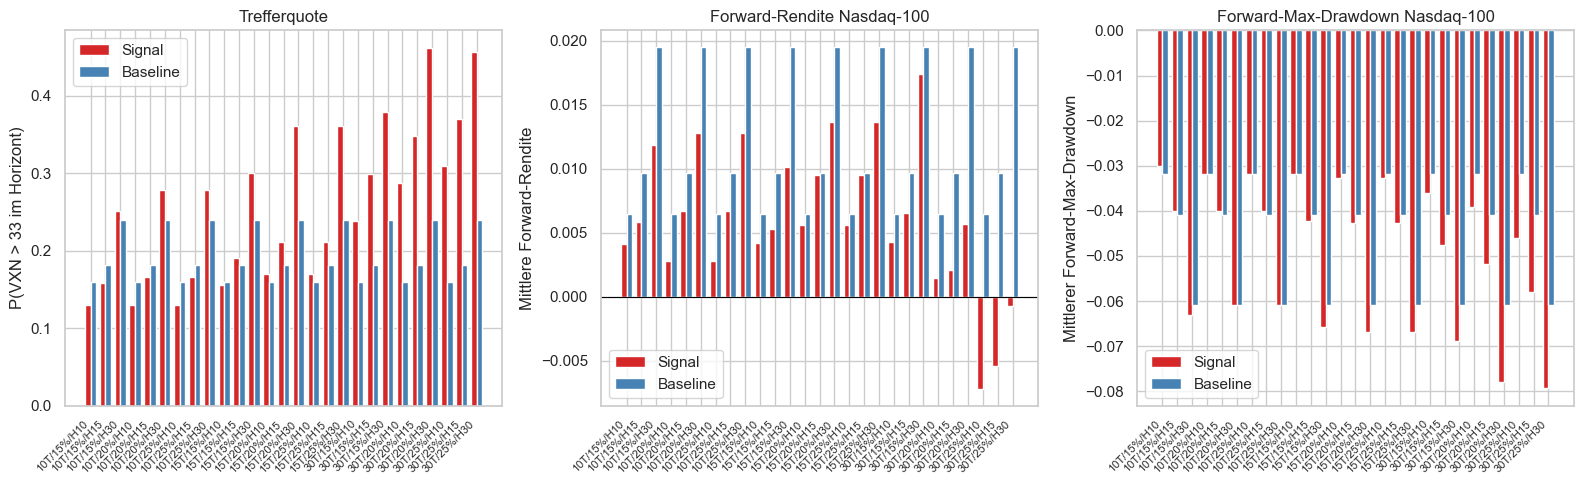

In [23]:
# Visualisierung nur für belastbare Kombinationen (>= MIN_SIGNALE Signale).
relevant = raster[raster["belastbar"]].copy()
if relevant.empty:
    print("Keine Kombination erreicht das Mindestkriterium - keine Visualisierung.")
else:
    relevant["label"] = (
        relevant["Fenster"].astype(int).astype(str) + "T/"
        + (relevant["Schwelle"] * 100).round().astype(int).astype(str) + "%/H"
        + relevant["Horizont"].astype(int).astype(str)
    )
    x = np.arange(len(relevant)); w = 0.38
    fig, (ax_t, ax_r, ax_d) = plt.subplots(1, 3, figsize=(16, 5))

    ax_t.bar(x - w/2, relevant["Trefferquote"], w, color=COLOR_RED, label="Signal")
    ax_t.bar(x + w/2, relevant["Trefferq_Baseline"], w, color="steelblue", label="Baseline")
    ax_t.set_ylabel("P(VXN > 33 im Horizont)")
    ax_t.set_title("Trefferquote")

    ax_r.bar(x - w/2, relevant["Fwd_Rendite"], w, color=COLOR_RED, label="Signal")
    ax_r.bar(x + w/2, relevant["Rendite_Baseline"], w, color="steelblue", label="Baseline")
    ax_r.axhline(0, color="black", linewidth=0.8)
    ax_r.set_ylabel("Mittlere Forward-Rendite")
    ax_r.set_title("Forward-Rendite Nasdaq-100")

    ax_d.bar(x - w/2, relevant["Fwd_MaxDD"], w, color=COLOR_RED, label="Signal")
    ax_d.bar(x + w/2, relevant["MaxDD_Baseline"], w, color="steelblue", label="Baseline")
    ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
    ax_d.set_title("Forward-Max-Drawdown Nasdaq-100")

    for ax in (ax_t, ax_r, ax_d):
        ax.set_xticks(x)
        ax.set_xticklabels(relevant["label"], rotation=45, ha="right", fontsize=8)
        ax.legend()
    plt.tight_layout(); plt.show()


**Ergebnis der Rasteranalyse:** Von den 27 Kombinationen erfüllen 27 das
Mindestkriterium von 30 Signaltagen. Eine niedrige Schwelle (15 %)
erzeugt viele, aber unspezifische Signale; höhere Schwellen (20–25 %) heben die
Turbulenz-Wahrscheinlichkeit deutlicher. Die trennschärfste belastbare Kombination
ist 30-Tage-Fenster/20 % (Horizont 30 Tage):
Trefferquote 46,1 % gegenüber 24,0 % Baseline.

Der entscheidende Unterschied zu den übrigen Signalen liegt in der
**Renditerichtung**: Die trennschärfsten Divergenz-Varianten sind die einzigen
Signale mit einer *unterdurchschnittlichen* Forward-Rendite des Nasdaq-100 (z. B.
30-Tage-Fenster/25 %, Horizont 10 Tage:
−0,72 % gegenüber +0,64 % Baseline). Während 3-Monats-Hoch
(4.6) und 3-Punkte-Umkehr (4.7) überdurchschnittliche Folgerenditen aufweisen und
damit reine *Volatilitätsflags* sind, trägt die Divergenz zusätzlich eine – wenn
auch schwache – *richtungsweisende* (leicht bearishe) Information.

**Praxisrelevanz für das Ampelsystem:** Die Divergenz kommt als langsames,
ergänzendes Warnsignal in Frage, das als einziges nicht nur erhöhte Schwankung,
sondern auch eine leicht negative Renditeerwartung anzeigt. Wegen der geringen
Effektstärke eignet sie sich als Zusatz-Indikator, nicht als eigenständiger
Ampel-Auslöser.

## 5. Einordnung und Handlungsempfehlungen

Die Hypothesenanalyse in Abschnitt 4 bewertet jedes Signal für sich. Dieser
Abschnitt ordnet die Befunde ein, indem er **die ampel-relevanten Signale
direkt gegenüberstellt**, um ihre *Charakteristik* zu vergleichen –
insbesondere die Frage, welche Signale dem VXN-Anstieg **vorlaufen** und
welche eher **gleichlaufend** auf bereits erhöhtem Niveau auftreten. Diese
Unterscheidung ergibt sich erst aus der einheitlichen Betrachtung mehrerer
Signale mit demselben Kennzahlensatz und ist der eigentliche Mehrwert dieses
Abschnitts gegenüber der Einzelauswertung in Kapitel 4.

**Darstellung:** Je Signal wird eine zweiteilige Grafik erstellt: oben der
VXN-Verlauf mit farblich hinterlegten Signaltagen, unten das
**Vorwärts-Profil** (Event-Study) – der gemittelte Pfad der VXN-Änderung in
den Handelstagen nach dem Signal. Da dieses Notebook explorativ ist und
keine handelbare Strategie backtestet, tritt das Vorwärts-Profil an die
Stelle einer Equity-Kurve. Verwendete Kennzahlen:

| Kennzahl | Bedeutung |
|---|---|
| Anteil Handelstage mit Signal | Häufigkeit des markierten Zustands. |
| Mittl. VXN-Änderung nach 5 / 10 Tagen | Typisches Ergebnis nach dem Signal: Beruhigung (fallend) vs. Eskalation (steigend). |
| Median max. VXN-Anstieg im Folgefenster | Beim VXN ist das Risiko ein Aufwärts-Ausschlag. |
| Trefferquote VXN > 33 vs. Baseline | Prognostischer Mehrwert (vgl. 3.1). |

**Auswahl der Signale:** Verglichen werden drei Signale mit unterschiedlicher
Charakteristik: das **neue 3-Monats-Hoch** (H6), die **Divergenz Block 6**
(H9) sowie das **Rot-Regime** (VXN ≥ 33) als Basis-Ampelzustand. Die
*3-Punkte-Umkehr* (H7) wird hier nicht erneut einzeln dargestellt, da ihr
Vorwärts-Verhalten bereits in Abschnitt 4.7 als eigene Event-Study analysiert
wurde; in der Gesamteinordnung unten wird sie dennoch berücksichtigt.


### 5.1 Vorbereitung: Signal-Katalog und Hilfsfunktionen

Zunächst werden die vier Signalmasken einheitlich auf dem gemeinsamen
Handelskalender definiert (konsistent zu den Definitionen aus Abschnitt 4)
sowie zwei zusätzliche Plot-Farben ergänzt. Die Funktion
`vertiefte_einzelbetrachtung` kapselt die zweiteilige Darstellung und die
Kennzahlen-Berechnung.


In [24]:
# --- Zusätzliche Plot-Farben für die 2-Panel-Darstellung
COLOR_PRICE = "#0b0b0b"   # VXN-Kurve (neutral/dunkel)
COLOR_MUTED = "#898781"   # Einzelpfade im Vorwärtsprofil

# --- Signal-Katalog: die vier repräsentativen Signale aus Kapitel 4 ----------
# Signal 1: Neues 3-Monats-Hoch (vgl. 4.6) - höchster Schlusskurs der letzten 63 Tage
sig_3m_hoch = df["vxn_close"] > df["vxn_close"].shift(1).rolling(63).max()

# Signal 2: 3-Punkte-Umkehr (vgl. 4.7) - Intraday-Hochschuss mit Rücksetzer zum Close
_ohlc = vxn[["Open", "High", "Low", "Close"]].reindex(df.index)
sig_umkehr = (
    (_ohlc["Open"] >= VXN_THRESHOLD_GELB)
    & (_ohlc["High"] > _ohlc["Open"])
    & ((_ohlc["High"] - _ohlc["Close"]) >= 3)
)

# Signal 3: Divergenz-Variante Block 6 (vgl. 4.9) - 20-Tage-Fenster, 20 %-Schwelle,
#           Index-Anstieg >= 0,25 %
_co_up = (df["nasdaq100_return"] > 0.25) & (df["vxn_change"] > 0)
sig_divergenz = _co_up.rolling(20).mean() > 0.20

# Signal 4: Rot-Regime (VXN >= 33, vgl. 4.4/4.5) - der Basis-Ampelzustand.
sig_rot = df["vxn_close"] >= VXN_THRESHOLD_ROT
sig_rot_eintritt = sig_rot & ~sig_rot.shift(1, fill_value=False)

print("Signal-Katalog erstellt:")
for _name, _maske in [("3-Monats-Hoch", sig_3m_hoch), ("3-Punkte-Umkehr", sig_umkehr),
                      ("Divergenz (Block 6)", sig_divergenz), ("Rot-Regime", sig_rot),
                      ("Rot-Eintritte", sig_rot_eintritt)]:
    print(f"  {_name:22s}: {int(_maske.sum()):4d} Tage")


Signal-Katalog erstellt:
  3-Monats-Hoch         :  180 Tage
  3-Punkte-Umkehr       :  193 Tage
  Divergenz (Block 6)   :  209 Tage
  Rot-Regime            :  469 Tage
  Rot-Eintritte         :   59 Tage


In [25]:
def vertiefte_einzelbetrachtung(name, phasen_maske, ereignis_maske=None,
                                horizon=10, titel=None, farbe=COLOR_RED):
    '''Zweiteilige Einzelbetrachtung eines Signals (analog zur SMA-Notebook-
    Systematik): oben der VXN-Verlauf mit farblich hinterlegten Signaltagen,
    darunter das gemittelte Vorwärtsprofil des VXN in den Tagen nach dem Signal
    (Event-Study). Gibt die Kennzahlen als dict zurück.'''
    titel = titel or name
    phasen = phasen_maske.reindex(df.index).fillna(False)
    ereignis = ereignis_maske if ereignis_maske is not None else phasen_maske
    ereignis = ereignis.reindex(df.index).fillna(False)

    vxn_werte = df["vxn_close"].values
    ereignis_idx = np.where(ereignis.values)[0]

    # Vorwärtsprofile relativ zum Signaltag + abgeleitete Kennzahlen
    pfade, max_anstiege = [], []
    treffer, gültig = 0, 0
    for i in ereignis_idx:
        if i + horizon >= len(vxn_werte):
            continue  # kein vollständiges Folgefenster mehr vorhanden
        basis = vxn_werte[i]
        pfade.append(vxn_werte[i : i + horizon + 1] - basis)
        nachfolger = vxn_werte[i + 1 : i + 1 + horizon]
        gültig += 1
        if nachfolger.max() > VXN_THRESHOLD_ROT:
            treffer += 1
        max_anstiege.append(nachfolger.max() - basis)
    pfade = np.array(pfade)
    mittel_pfad = pfade.mean(axis=0)
    median_pfad = np.median(pfade, axis=0)

    anteil_tage = phasen.mean()
    trefferquote = treffer / gültig if gültig else np.nan
    änderung_5 = mittel_pfad[5] if horizon >= 5 else np.nan
    änderung_10 = mittel_pfad[horizon]
    median_max_anstieg = float(np.median(max_anstiege)) if max_anstiege else np.nan

    # --- 2-Panel-Plot: oben VXN + Signalphasen, unten Vorwärtsprofil
    fig, (ax_vix, ax_fwd) = plt.subplots(2, 1, figsize=(12, 7))

    ax_vix.fill_between(df.index, 0, 1, where=phasen.values, color=farbe, alpha=0.15,
                        transform=ax_vix.get_xaxis_transform())
    ax_vix.plot(df.index, df["vxn_close"], color=COLOR_PRICE, linewidth=0.8)
    ax_vix.axhline(VXN_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", linewidth=1,
                   label=f"Rot-Schwelle ({VXN_THRESHOLD_ROT})")
    ax_vix.set_ylabel("VXN")
    ax_vix.set_title(f"{titel} – farblich hinterlegt: Signaltage")
    ax_vix.legend(loc="upper right")

    tage = np.arange(0, horizon + 1)
    for p in pfade:
        ax_fwd.plot(tage, p, color=COLOR_MUTED, alpha=0.12, linewidth=0.7)
    ax_fwd.plot(tage, mittel_pfad, color=farbe, linewidth=2.5, label="Mittelwert")
    ax_fwd.plot(tage, median_pfad, color="black", linewidth=2, linestyle="--", label="Median")
    ax_fwd.axhline(0, color="black", linewidth=0.8)
    ax_fwd.set_xlabel("Handelstage nach Signal")
    ax_fwd.set_ylabel("VXN-Änderung ggü. Signaltag (Punkte)")
    ax_fwd.set_title("Gemitteltes Vorwärtsprofil (graue Linien = Einzelfälle)")
    ax_fwd.legend(loc="upper left")

    fig.tight_layout()
    plt.show()

    print(f"Anteil Handelstage mit Signal:             {anteil_tage:.1%}  ({int(phasen.sum())} Tage)")
    print(f"Auswertbare Ereignisse (Vorwärtsprofil):   {gültig}")
    print(f"Trefferquote VXN > {VXN_THRESHOLD_ROT} in {horizon} Tagen:         {trefferquote:.1%}  (Baseline: {baseline_10:.1%})")
    print(f"Mittl. VXN-Änderung nach 5 / {horizon} Tagen:     {änderung_5:+.2f} / {änderung_10:+.2f} Punkte")
    print(f"Median max. VXN-Anstieg im {horizon}-Tage-Fenster:  {median_max_anstieg:+.2f} Punkte")

    return {"name": name, "anteil_tage": anteil_tage, "trefferquote": trefferquote,
            "änderung_5": änderung_5, "änderung_10": änderung_10,
            "median_max_anstieg": median_max_anstieg, "n_ereignisse": gültig}


### 5.2 Einzelbetrachtung der repräsentativen Signale

Für jedes Signal folgen die zweiteilige Grafik, die Kennzahlen sowie eine
kurze Ergebnis- und Praxiseinordnung.


#### Signal 1 – Neues 3-Monats-Hoch (H6)


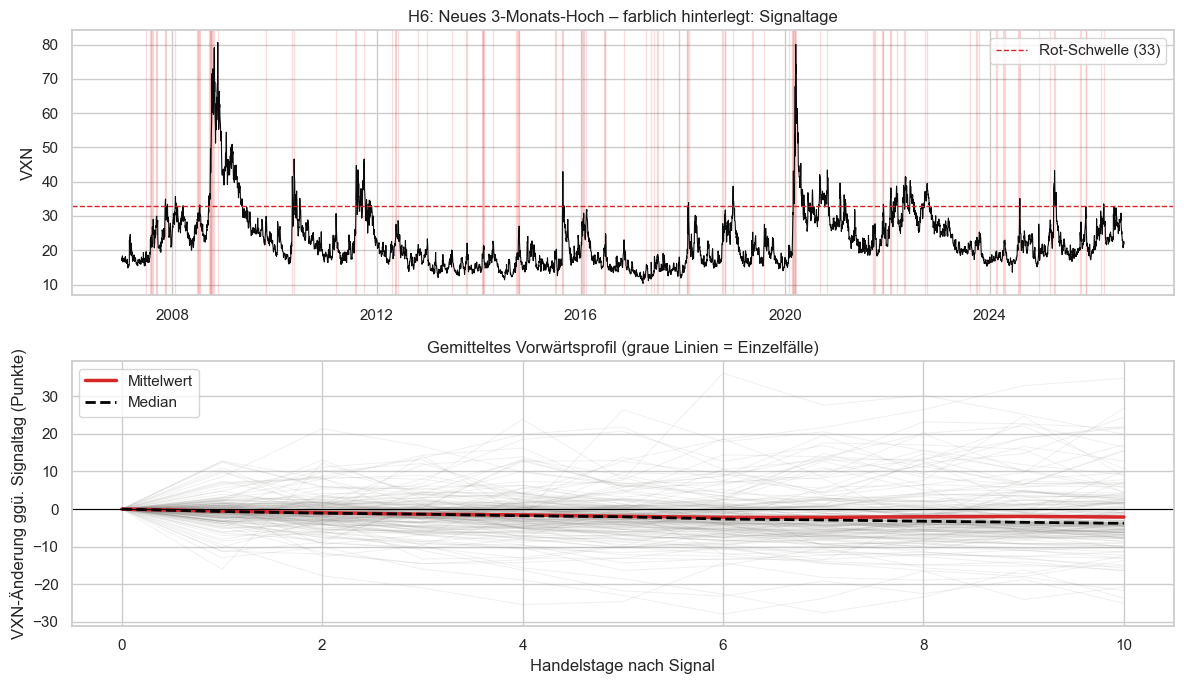

Anteil Handelstage mit Signal:             3.6%  (180 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   180
Trefferquote VXN > 33 in 10 Tagen:         42.2%  (Baseline: 15.9%)
Mittl. VXN-Änderung nach 5 / 10 Tagen:     -1.94 / -2.12 Punkte
Median max. VXN-Anstieg im 10-Tage-Fenster:  +1.64 Punkte


In [26]:
res_3m = vertiefte_einzelbetrachtung(
    "3-Monats-Hoch", sig_3m_hoch, titel="H6: Neues 3-Monats-Hoch", farbe=COLOR_RED)


**Ergebnis:** Das Signal markiert 3,7 % der Handelstage
(180 Ereignisse). Die Trefferquote für VXN > 33 innerhalb von 10 Tagen
liegt mit 42,2 % über der
Baseline (15,9 %). Im Mittel *fällt* der VXN nach dem Signal jedoch
(−1,94 nach 5, −2,12 nach 10 Tagen), und der mediane maximale
Weiter-Anstieg ist mit +1,64 Punkten gering – ein neues
3-Monats-Hoch tritt oft bereits auf erhöhtem Niveau auf, das anschließend eher
mean-revertiert.

**Praxisrelevanz für das Ampelsystem:** Das Signal taugt als Frühwarn-Flag für
eine erhöhte Rot-Bereitschaft, nicht als Vorbote einer weiteren Eskalation –
passend zur Rolle als dezentes „Vorsicht"-Nebensignal neben der Hauptampel.

#### Signal 2 – Divergenz (Block 6, H9)


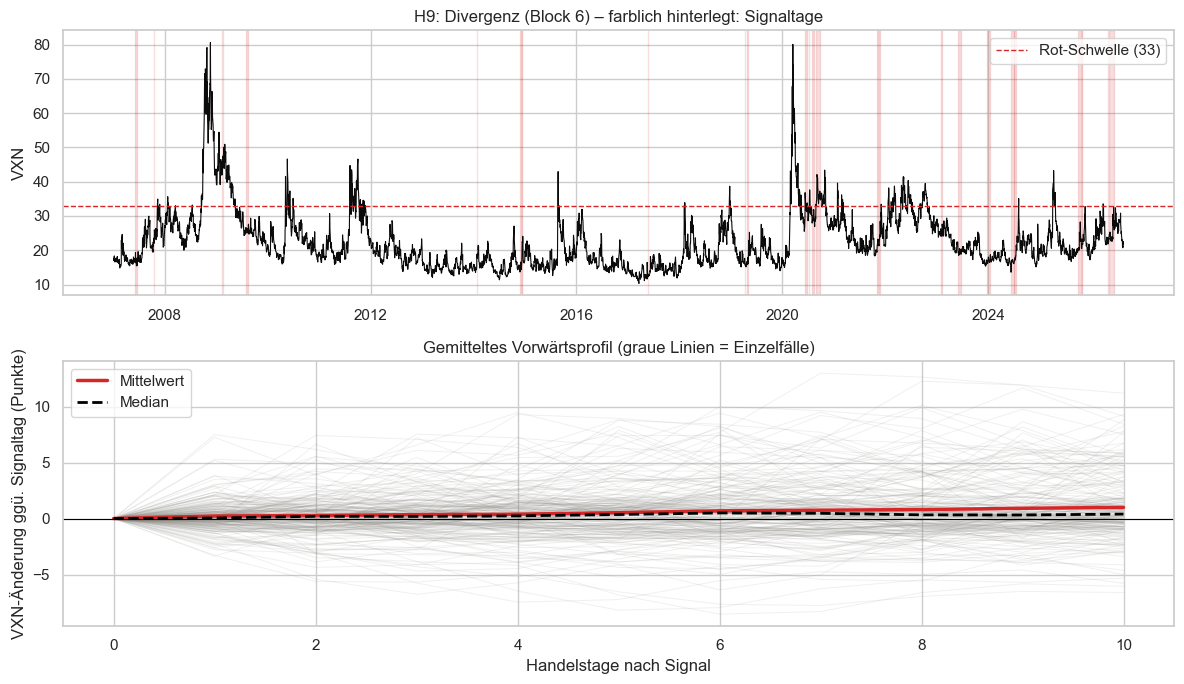

Anteil Handelstage mit Signal:             4.2%  (209 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   209
Trefferquote VXN > 33 in 10 Tagen:         22.0%  (Baseline: 15.9%)
Mittl. VXN-Änderung nach 5 / 10 Tagen:     +0.53 / +1.00 Punkte
Median max. VXN-Anstieg im 10-Tage-Fenster:  +2.15 Punkte


In [27]:
res_div = vertiefte_einzelbetrachtung(
    "Divergenz (Block 6)", sig_divergenz, titel="H9: Divergenz (Block 6)", farbe=COLOR_RED)


**Ergebnis:** Dieses Signal verhält sich als einziges qualitativ anders: Sein
Vorwärtsprofil *steigt* (+0,53 nach 5, +1,00 nach 10 Tagen),
und der mediane maximale Anstieg ist mit +2,15 Punkten der größte aller
Signale. Die Trefferquote liegt mit 22,0 %
über der Baseline (15,9 %). Bei
4,2 % der Tage (209 Ereignisse) markiert es eine Phase *vor* dem
Anstieg.

**Praxisrelevanz für das Ampelsystem:** Anders als die übrigen Signale, die auf
bereits erhöhtem Niveau auftreten und mean-revertieren, ist die Divergenz Block 6
der einzige *vorlaufende* Kandidat im Katalog – er kann anschlagen, bevor die
Hauptampel auf Rot springt (bei allerdings schmaler Datenbasis).

#### Signal 3 – Rot-Regime (VXN ≥ 33)


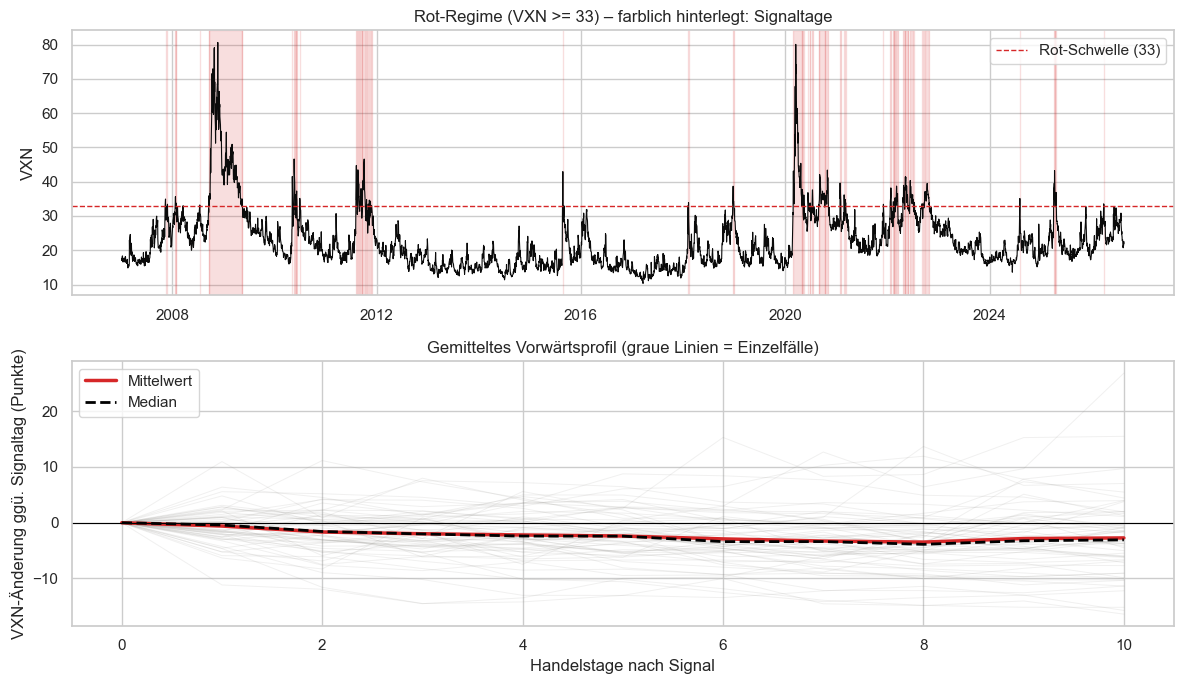

Anteil Handelstage mit Signal:             9.5%  (469 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   59
Trefferquote VXN > 33 in 10 Tagen:         88.1%  (Baseline: 15.9%)
Mittl. VXN-Änderung nach 5 / 10 Tagen:     -2.38 / -2.73 Punkte
Median max. VXN-Anstieg im 10-Tage-Fenster:  +1.12 Punkte


In [28]:
res_rot = vertiefte_einzelbetrachtung(
    "Rot-Regime", sig_rot, ereignis_maske=sig_rot_eintritt,
    titel="Rot-Regime (VXN >= 33)", farbe=COLOR_RED)


**Ergebnis:** Der VXN ist an 9,5 % der Tage im Rot-Bereich;
ausgewertet werden die 59 Eintrittsereignisse. Erwartungsgemäß ist die
Trefferquote trivial hoch (88,1 %), da der VXN beim Eintritt
bereits nahe 33 liegt. Das Vorwärtsprofil fällt danach im Mittel deutlich
(−2,38 / −2,73), ein großer weiterer Anstieg ist selten
(medianer max. Anstieg nur +1,12).

**Praxisrelevanz für das Ampelsystem:** Ein Rot-Eintritt ist meist ein kurzer
Ausschlag mit anschließender Beruhigung, kein Auftakt zu immer weiter steigender
Panik. Das stützt die Empfehlung, einen einzelnen Rot-Tag nicht zu überzeichnen
und erst bei mehrtägiger Persistenz zu eskalieren.

### 5.3 Konsolidierte Übersicht und Einordnung

Gegenüberstellung der vier Signale anhand der VXN-spezifischen Kennzahlen.


In [29]:
übersicht = pd.DataFrame([res_3m, res_div, res_rot]).set_index("name")
übersicht_anzeige = pd.DataFrame({
    "Anteil Tage": übersicht["anteil_tage"].map(lambda x: f"{x:.1%}"),
    "Ereignisse": übersicht["n_ereignisse"].astype(int),
    "Trefferquote (VXN>33/10T)": übersicht["trefferquote"].map(lambda x: f"{x:.1%}"),
    "VXN-Änderung 5T": übersicht["änderung_5"].map(lambda x: f"{x:+.2f}"),
    "VXN-Änderung 10T": übersicht["änderung_10"].map(lambda x: f"{x:+.2f}"),
    "Median max. Anstieg 10T": übersicht["median_max_anstieg"].map(lambda x: f"{x:+.2f}"),
})
übersicht_anzeige.insert(0, "Baseline (VXN>33/10T)", f"{baseline_10:.1%}")
print(übersicht_anzeige.to_string())


                    Baseline (VXN>33/10T) Anteil Tage  Ereignisse Trefferquote (VXN>33/10T) VXN-Änderung 5T VXN-Änderung 10T Median max. Anstieg 10T
name                                                                                                                                                
3-Monats-Hoch                       15.9%        3.6%         180                     42.2%           -1.94            -2.12                   +1.64
Divergenz (Block 6)                 15.9%        4.2%         209                     22.0%           +0.53            +1.00                   +2.15
Rot-Regime                          15.9%        9.5%          59                     88.1%           -2.38            -2.73                   +1.12


**Zusammenfassende Einordnung:** Die Signale zerfallen in zwei
Charakteristiken. **Gleichlaufende/beruhigende Signale** treten auf bereits
erhöhtem VXN-Niveau auf und zeigen ein im Mittel *fallendes* Vorwärtsprofil: das
3-Monats-Hoch (−2,12 nach 10 Tagen), der Rot-Eintritt (−2,73)
und – in Abschnitt 4.7 gezeigt – die 3-Punkte-Umkehr (−1,67). Sie
beschreiben den *aktuellen* Zustand. Demgegenüber ist die **Divergenz Block 6** das
einzige Signal mit *steigtdem* Vorwärtsprofil (+1,00) und dem größten
medianen Folge-Anstieg (+2,15) – und damit der einzige echte
*vorlaufende* Frühindikator-Kandidat im Katalog (bei noch schmaler Datenbasis von
209 Fällen). Alle Kennzahlen sind explorativ und beschreiben historische
Durchschnitte, keine garantierten Prognosen.

## 6. Ampel-Systematik auf Basis des VXN

Die vorangegangenen Abschnitte liefern die empirische Grundlage für die
Ampel-Kategorien Grün/Gelb/Rot; dieser Abschnitt fasst sie zu einer
konkreten Kategorienregel zusammen und validiert sie statistisch.


### 6.1 Kategorienregel und empirische Grundlage der Schwellenwerte

Die Ampel klassifiziert jeden Handelstag anhand des VXN-Schlusskurses:
**Grün** (VXN < 23), **Gelb** (23 ≤ VXN < 33) und **Rot** (VXN ≥ 33). Anders
als beim VIX sind diese Schwellen nicht als Faustregel gesetzt, sondern
datenbasiert aus der VXN-eigenen Verteilung abgeleitet (Abschnitt 4.4), sodass
sich vergleichbare Ampel-Anteile wie beim VIX ergeben. Abschnitt 4.8 bestätigt,
dass der Median-VXN innerhalb bekannter Stressphasen (36,4) nahe am 90.
Perzentil der Gesamtverteilung (32,7) liegt und deutlich über dem 75.
Perzentil (26,4) – die Rot-Schwelle trifft damit real beobachtetes
Krisenverhalten. Mit diesen Schwellen verteilen sich die Handelstage auf Grün
62,2 %, Gelb 28,3 % und Rot 9,5 % (Abschnitt 4.4). Abschnitt 4.5 zeigt zudem,
dass Rot-Phasen meist kurz sind (Median 2 Handelstage), in echten Krisen aber
bis zu 163 Tage andauern können – daraus folgt die in 6.3 formulierte
Eskalationsregel für mehrtägiges Rot.


### 6.2 Statistische Validierung der Ampelfarben

Die in Abschnitt 4.1 berechneten Forward-Kennzahlen des Nasdaq-100 je
VXN-Ausgangsniveau (Baseline, VXN > 23, VXN > 33) dienen zugleich als
statistische Validierung der Ampelfarben: Sie zeigen, ob sich Gelb- und
Rot-Tage im Anschluss auch tatsächlich in Rendite und Risiko des Index vom
Grün-Zustand unterscheiden.


In [30]:
print(f"Auswertbare Tage - Baseline: {n_base}, >23: {n_g}, >33: {n_r}")
print(disp_h1.to_string())


Auswertbare Tage - Baseline: 4905, >23: 1839, >33: 468
         Rend. Baseline Rend. >23 Rend. >33 MaxDD Baseline MaxDD >23 MaxDD >33
Horizont                                                                      
5T               +0.33%    +0.40%    +0.68%         -1.97%    -2.89%    -4.09%
10T              +0.65%    +0.79%    +1.02%         -3.19%    -4.49%    -6.28%
15T              +0.97%    +1.17%    +1.86%         -4.10%    -5.64%    -7.53%
30T              +1.95%    +2.58%    +4.09%         -6.09%    -7.98%    -9.87%


**Ergebnis:** Nach VXN > 33 fällt die Forward-Rendite des Nasdaq-100 über
30 Tage höher aus als nach der Baseline (+4,09 % gegenüber +1,95 %), der
Forward-Max-Drawdown zugleich deutlich tiefer (−9,87 % gegenüber −6,09 %). Die
Ampel trennt damit vor allem das **Risiko** trennscharf, während die Rendite
in die dem naiven Erwarten entgegengesetzte Richtung zeigt (vgl. H2, Abschnitt
4.2) – ein Muster, das sich mit der Rolle des VXN als zeitgleichem
Stressindikator deckt, dessen Spitzen historisch nahe an Markttiefs liegen.


### 6.3 Abgeleitete Ampel-Logik

| Ampelfarbe | Basis-Kriterium | Optionaler Zusatzhinweis |
|---|---|---|
| Grün | VXN < 23 | „Vorsicht“-Flag bei aktivem 3-Monats-Hoch-Signal (H6) |
| Gelb | 23 ≤ VXN < 33 | – |
| Rot | VXN ≥ 33 | Hinweis „mögliche baldige Beruhigung“ bei 3-Punkte-Umkehr (H7) |

Bei mehrtägig anhaltendem Rot (Abschnitt 4.5) empfiehlt sich zusätzlich eine
Eskalationsstufe, die kurzfristiges Rauschen von echten Krisenphasen trennt
(z. B. „Rot an 3+ Tagen in Folge = erhöhte Warnstufe“).


## 7. Was-wäre-wenn-Analyse: Wirkung des VXN-gestützten Risikoausschlusses

Die bisherigen Abschnitte beschreiben den Marktzustand. Dieser Abschnitt nimmt
die Perspektive einer Anlegerin ein und beantwortet die Frage direkt: **Wie
hätte sich die Wertentwicklung des Nasdaq-100 unterschieden, wenn man an den vom
VXN als riskant eingestuften Tagen nicht investiert gewesen wäre?** Dazu wird
die Wertentwicklung von **Buy & Hold** (durchgehend im Nasdaq-100 investiert) einer
**Ausschluss-Strategie** gegenübergestellt, die an VXN-Risikotagen in Cash geht.

**Methodische Abgrenzung:** Das VXN-Signal ist am jeweiligen Handelsschluss
bekannt und wird um einen Tag verschoben angewendet (Entscheidung am
Vortagsschluss → die Strategie ist frei von Rückschaufehlern/Look-ahead-Bias).
An ausgeschlossenen Tagen beträgt die Tagesrendite 0 %. Vereinfachend werden
**Transaktionskosten und eine Verzinsung der Cash-Position nicht** berücksichtigt.
Die Ergebnisse zeigen daher das **theoretische Potenzial** einer VXN-gestützten
Risikosteuerung, nicht die realistisch erzielbare Rendite einer handelbaren Strategie.

**Wichtiger Vorbehalt zum VXN:** Hohe VXN-Werte markieren historisch nicht nur
Abschwünge, sondern fallen oft mit dem Tiefpunkt und der anschließenden,
besonders kräftigen Erholung zusammen. Ein Ausschluss von Hoch-VXN-Tagen
vermeidet daher zwar Verlusttage, kann aber auch starke Erholungstage verpassen –
dieser Zielkonflikt ist bei der Interpretation der Renditen zentral.


### 7.1 Backtest-Hilfsfunktionen

`was_wäre_wenn` berechnet für eine gegebene Risikomaske die Wertentwicklung
beider Varianten sowie Gesamtrendite, annualisierte Rendite (CAGR) und den
historischen maximalen Drawdown.


In [31]:
def historischer_max_drawdown(werte):
    # Klassischer Peak-to-Trough-Drawdown einer kumulierten Wertreihe.
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_wäre_wenn(risiko_maske, label):
    '''Simuliert eine Strategie, die an VXN-Risikotagen in Cash geht (Tagesrendite 0,
    ohne Cash-Verzinsung und Transaktionskosten) und sonst voll im Nasdaq-100 investiert
    ist. Das VXN-Signal wird um einen Tag verschoben angewendet (Entscheidung am
    Vortagsschluss -> kein Look-ahead-Bias). Vergleich mit Buy & Hold.'''
    tagesrendite = df["nasdaq100_close"].pct_change().fillna(0)
    risiko = risiko_maske.reindex(df.index).fillna(False).shift(1, fill_value=False)

    strategie_rendite = tagesrendite.where(~risiko, 0.0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity):
        gesamt = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamt, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "risikophase": label,
        "anteil_risikotage": risiko.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 7.2 VXN-Risikophasen-Definitionen

Aus den Erkenntnissen der Kapitel 4 und 5 werden fünf Risikophasen abgeleitet.
Für die ereignisbasierten Signale (3-Monats-Hoch, Divergenz Block 6) gilt das
Risiko am Signaltag und den darauf folgenden 9 Handelstagen (10-Tage-Fenster,
konsistent zur Turbulenz-Definition aus Abschnitt 4.6):

- **Rot (VXN ≥ 33)** – der Ausnahmezustand der Ampel.
- **Gelb+Rot (VXN ≥ 23)** – alle angespannten und schlimmeren Tage.
- **3-Monats-Hoch (+10 Tage)** – Frühwarnfenster nach einem neuen 3-Monats-Hoch (H6).
- **Divergenz Block 6 (+10 Tage)** – Fenster nach dem vorlaufenden Divergenzsignal (H9).
- **Kombiniert (Rot oder Block 6)** – Rot-Zustand ODER laufendes Block-6-Frühwarnfenster.


In [32]:
# Nachlauf-Fenster: Risiko gilt am Signaltag und den folgenden k-1 Handelstagen
def nachlauf(signal, k=10):
    maske = signal.reindex(df.index).fillna(False)
    return maske.rolling(k, min_periods=1).max().astype(bool)

_sig_3m_hoch = df["vxn_close"] > df["vxn_close"].shift(1).rolling(63).max()
_co_up = (df["nasdaq100_return"] > 0.25) & (df["vxn_change"] > 0)
_sig_divergenz = _co_up.rolling(20).mean() > 0.20

risiko_definitionen = {
    "Rot (VXN >= 33)":            df["vxn_close"] >= VXN_THRESHOLD_ROT,
    "Gelb+Rot (VXN >= 23)":      df["vxn_close"] >= VXN_THRESHOLD_GELB,
    "3-Monats-Hoch (+10 Tage)":   nachlauf(_sig_3m_hoch, 10),
    "Divergenz Block 6 (+10 Tage)": nachlauf(_sig_divergenz, 10),
}
risiko_definitionen["Kombiniert (Rot oder Block 6)"] = (
    (df["vxn_close"] >= VXN_THRESHOLD_ROT) | nachlauf(_sig_divergenz, 10)
)

print("VXN-Risikophasen (Anteil der Handelstage):")
for _name, _maske in risiko_definitionen.items():
    print(f"  {_name:32s}: {_maske.mean():.1%}")


VXN-Risikophasen (Anteil der Handelstage):
  Rot (VXN >= 33)                 : 9.5%
  Gelb+Rot (VXN >= 23)            : 37.7%
  3-Monats-Hoch (+10 Tage)        : 18.1%
  Divergenz Block 6 (+10 Tage)    : 8.1%
  Kombiniert (Rot oder Block 6)   : 16.5%


### 7.3 Konsolidierte Kennzahlenübersicht

Für alle fünf Risikophasen werden Gesamtrendite, CAGR und maximaler Drawdown
von Buy & Hold der jeweiligen Ausschluss-Strategie gegenübergestellt.


In [33]:
ergebnisse_www = [was_wäre_wenn(maske, name) for name, maske in risiko_definitionen.items()]
tabelle_www = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])

anzeige = pd.DataFrame({
    "Anteil Risikotage": tabelle_www["anteil_risikotage"].map(lambda x: f"{x:.1%}"),
    "Gesamtrend. B&H": tabelle_www["gesamtrendite_buy_hold"].map(lambda x: f"{x:.0%}"),
    "Gesamtrend. Strat.": tabelle_www["gesamtrendite_strategie"].map(lambda x: f"{x:.0%}"),
    "CAGR B&H": tabelle_www["cagr_buy_hold"].map(lambda x: f"{x:.1%}"),
    "CAGR Strat.": tabelle_www["cagr_strategie"].map(lambda x: f"{x:.1%}"),
    "Max DD B&H": tabelle_www["max_drawdown_buy_hold"].map(lambda x: f"{x:.1%}"),
    "Max DD Strat.": tabelle_www["max_drawdown_strategie"].map(lambda x: f"{x:.1%}"),
})
anzeige.index = tabelle_www["risikophase"]
print(anzeige.to_string())


                              Anteil Risikotage Gesamtrend. B&H Gesamtrend. Strat. CAGR B&H CAGR Strat. Max DD B&H Max DD Strat.
risikophase                                                                                                                     
Rot (VXN >= 33)                            9.5%           1580%               654%    15.5%       10.8%     -53.7%        -41.8%
Gelb+Rot (VXN >= 23)                      37.7%           1580%               399%    15.5%        8.5%     -53.7%        -21.5%
3-Monats-Hoch (+10 Tage)                  18.1%           1580%               721%    15.5%       11.3%     -53.7%        -44.2%
Divergenz Block 6 (+10 Tage)               8.1%           1580%              1500%    15.5%       15.2%     -53.7%        -53.4%
Kombiniert (Rot oder Block 6)             16.5%           1580%               523%    15.5%        9.8%     -53.7%        -41.3%


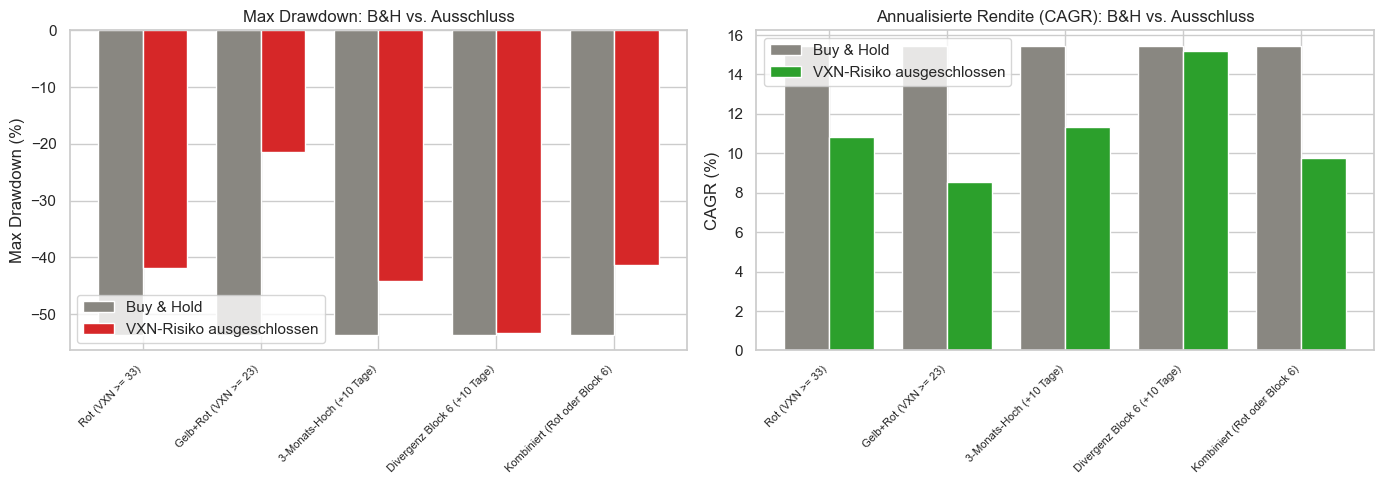

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(tabelle_www)); breite = 0.38
namen = tabelle_www["risikophase"]

ax1.bar(x - breite/2, tabelle_www["max_drawdown_buy_hold"]*100, breite, label="Buy & Hold", color=COLOR_MUTED)
ax1.bar(x + breite/2, tabelle_www["max_drawdown_strategie"]*100, breite, label="VXN-Risiko ausgeschlossen", color=COLOR_RED)
ax1.set_xticks(x); ax1.set_xticklabels(namen, rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Max Drawdown (%)"); ax1.set_title("Max Drawdown: B&H vs. Ausschluss"); ax1.legend()

ax2.bar(x - breite/2, tabelle_www["cagr_buy_hold"]*100, breite, label="Buy & Hold", color=COLOR_MUTED)
ax2.bar(x + breite/2, tabelle_www["cagr_strategie"]*100, breite, label="VXN-Risiko ausgeschlossen", color=COLOR_GREEN)
ax2.set_xticks(x); ax2.set_xticklabels(namen, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("CAGR (%)"); ax2.set_title("Annualisierte Rendite (CAGR): B&H vs. Ausschluss"); ax2.legend()

plt.tight_layout(); plt.show()


**Ergebnis:** Buy & Hold erzielt über den Zeitraum 1584 %
Gesamtrendite (CAGR 15,5 %) bei einem maximalen Drawdown von
−53,7 %. Über alle fünf Risikophasen hinweg **reduziert der
VXN-gestützte Ausschluss die Rendite** – wie beim VIX, anders als im
trendbasierten SMA-Notebook. Der Ausschluss der Rot-Tage (VXN ≥ 33,
9,5 % der Tage) drückt die CAGR auf 10,9 %, der Max
Drawdown sinkt auf −41,8 %. Am aggressivsten wirkt Gelb+Rot
(VXN ≥ 23): Drawdown −21,5 %, CAGR aber nur noch 8,5 %.
Die ereignisbasierten Signale (3-Monats-Hoch, Block 6) bewegen die Gesamtbilanz
kaum.

**Ursache:** Hohe VXN-Werte fallen historisch mit Markttiefpunkten und den
anschließenden, besonders kräftigen Erholungstagen zusammen. Wer an
Hoch-VXN-Tagen in Cash geht, vermeidet Verlusttage, verpasst aber auch die
stärksten Rebounds – der VXN wirkt als Risikoreduzierer, nicht als
Renditebringer (im Einklang mit H2).

### 7.4 Vertiefte Einzelbetrachtung ausgewählter Risikophasen

Für drei repräsentative Fälle wird der zeitliche Verlauf dargestellt: oben der
Nasdaq-100-Kurs mit rot hinterlegter Ausschlussphase, darunter die Wertentwicklung
von Buy & Hold gegenüber der Ausschluss-Strategie (logarithmische Skala,
Startwert = 1).


In [35]:
def plotte_was_wäre_wenn(label, titel=None):
    ergebnis = was_wäre_wenn(risiko_definitionen[label], label)
    risiko = risiko_definitionen[label].reindex(df.index).fillna(False).shift(1, fill_value=False)
    titel = titel or label

    fig, (ax_kurs, ax_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    ax_kurs.fill_between(df.index, 0, 1, where=risiko.values, color=COLOR_RED, alpha=0.15,
                         transform=ax_kurs.get_xaxis_transform())
    ax_kurs.plot(df.index, df["nasdaq100_close"], color=COLOR_PRICE, linewidth=0.9)
    ax_kurs.set_ylabel("Nasdaq-100 (Punkte)")
    ax_kurs.set_title(f"{titel} - rot hinterlegt: ausgeschlossene VXN-Risikophase")

    ax_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    ax_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_GREEN, label="VXN-Risiko ausgeschlossen")
    ax_equity.set_yscale("log")
    ax_equity.set_ylabel("Wertentwicklung (Start = 1, log.)")
    ax_equity.legend()

    fig.tight_layout(); plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_risikotage']:.1%}")
    print(f"Gesamtrendite - B&H: {ergebnis['gesamtrendite_buy_hold']:.0%} | Strategie: {ergebnis['gesamtrendite_strategie']:.0%}")
    print(f"CAGR         - B&H: {ergebnis['cagr_buy_hold']:.1%} | Strategie: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown - B&H: {ergebnis['max_drawdown_buy_hold']:.1%} | Strategie: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


#### Rot (VXN ≥ 33) ausgeschlossen


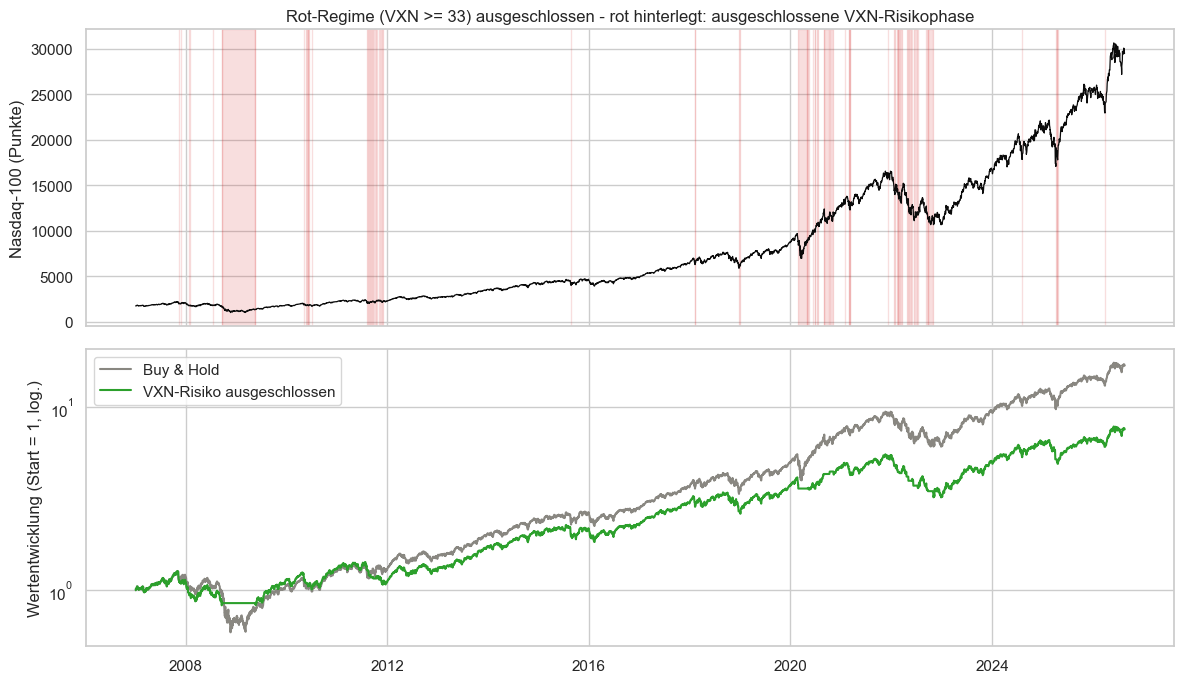

Anteil ausgeschlossener Handelstage: 9.5%
Gesamtrendite - B&H: 1580% | Strategie: 654%
CAGR         - B&H: 15.5% | Strategie: 10.8%
Max Drawdown - B&H: -53.7% | Strategie: -41.8%


In [36]:
_ = plotte_was_wäre_wenn("Rot (VXN >= 33)", "Rot-Regime (VXN >= 33) ausgeschlossen")


**Ergebnis:** Der Ausschluss der 9,5 % Rot-Tage verändert den
Max Drawdown von −53,7 % auf −41,8 % und drückt die CAGR von
15,5 % auf 10,9 % (Gesamtrendite 656 % statt
1584 %). In den Crashphasen bleibt die Strategie flach, verpasst danach
aber die V-förmigen Erholungen und bleibt so unter Buy & Hold.

#### Gelb+Rot (VXN ≥ 23) ausgeschlossen


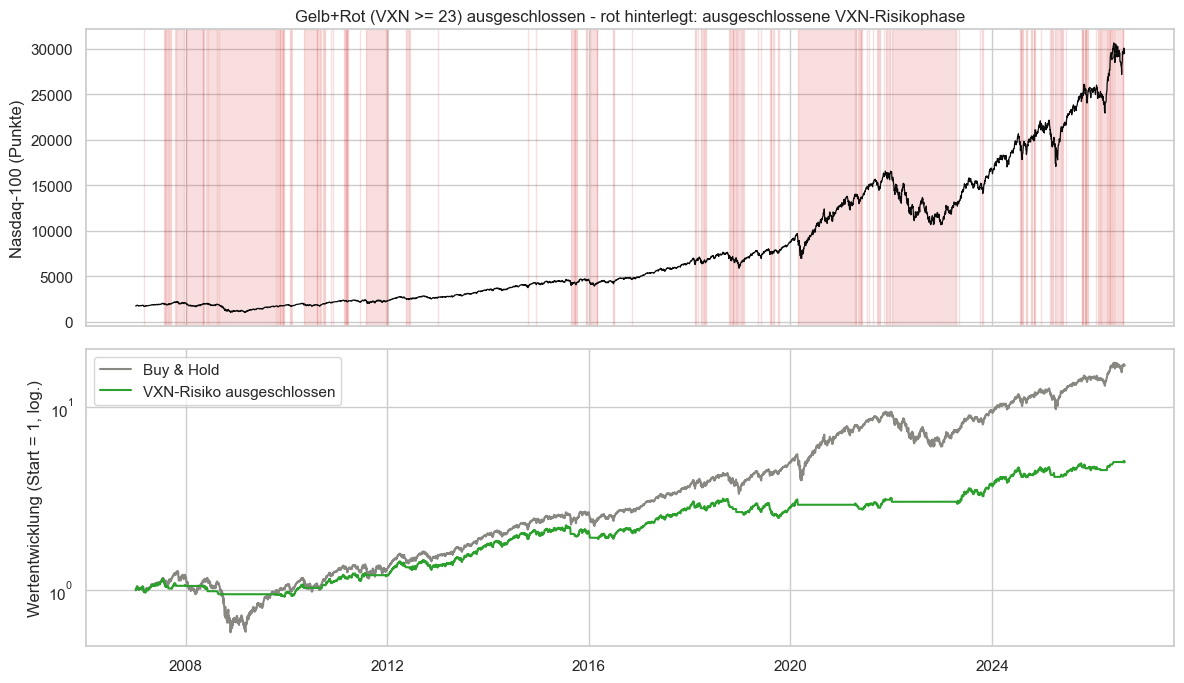

Anteil ausgeschlossener Handelstage: 37.7%
Gesamtrendite - B&H: 1580% | Strategie: 399%
CAGR         - B&H: 15.5% | Strategie: 8.5%
Max Drawdown - B&H: -53.7% | Strategie: -21.5%


In [37]:
_ = plotte_was_wäre_wenn("Gelb+Rot (VXN >= 23)", "Gelb+Rot (VXN >= 23) ausgeschlossen")


**Ergebnis:** Das aggressivste Filter (37,8 % der Tage in Cash)
senkt den Max Drawdown deutlich auf −21,5 %, kostet aber massiv Rendite:
Die CAGR sinkt auf 8,5 % (Gesamtrendite 399 % statt
1584 %). Ein deutlich ruhigeres Depot – der Renditeverzicht ist jedoch
für die meisten Anlegerinnen zu hoch.

#### Kombinierte Regel (Rot oder Block 6) ausgeschlossen


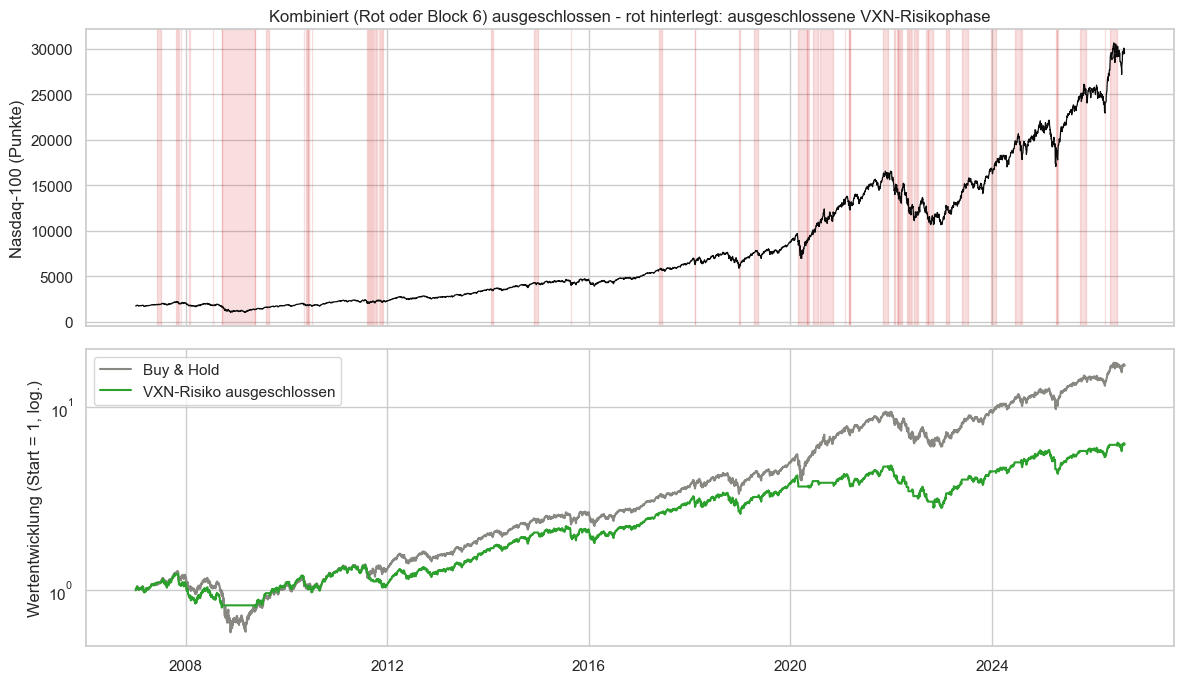

Anteil ausgeschlossener Handelstage: 16.5%
Gesamtrendite - B&H: 1580% | Strategie: 523%
CAGR         - B&H: 15.5% | Strategie: 9.8%
Max Drawdown - B&H: -53.7% | Strategie: -41.3%


In [38]:
_ = plotte_was_wäre_wenn("Kombiniert (Rot oder Block 6)", "Kombiniert (Rot oder Block 6) ausgeschlossen")


**Ergebnis:** Die Kombination (Rot oder Block 6, 16,5 % der Tage)
liegt nahe am reinen Rot-Ausschluss: Max Drawdown −41,3 %, CAGR
9,8 %. Der vorlaufende Block-6-Filter verbessert das aggregierte
Portfolio-Ergebnis also nicht spürbar – sein Wert liegt in der frühen
Einzelwarnung (Kapitel 5), nicht in der Portfolio-Steuerung.

### 7.5 Zusammenfassende Einordnung

Die Was-wäre-wenn-Analyse liefert den zentralen, ehrlichen Befund: Ein
VXN-gestützter Risikoausschluss **kostet Rendite** (CAGR von 15,5 % auf
10,9 % bei Rot-Ausschluss); die Drawdown-Wirkung reicht von gering (Rot) bis
deutlich (Gelb+Rot: −53,7 % → −21,5 %). Der Grund liegt in der Natur des
VXN: Er ist ein zeitgleicher Stressindikator, dessen Spitzen mit Tiefpunkten
und den darauffolgenden Erholungen zusammenfallen.

**Für das Ampelsystem** heißt das: Der Nutzen liegt in der Drawdown-Begrenzung
(sicherheitsorientierte Anlegerinnen), nicht in der Renditesteigerung. Die
Ampel sollte als **Risiko-, nicht als Renditesignal** kommuniziert werden.
Alle Werte beruhen auf einer vereinfachten Simulation ohne Transaktionskosten
und Cash-Verzinsung und markieren ein oberes Potenzial.


## 8. Export der Ergebnisse

Sämtliche Ergebnistabellen dieses Notebooks werden als CSV-Dateien sowie als
gemeinsame Excel-Arbeitsmappe im Ordner `Hypothesenanalysen/` gespeichert.


In [39]:
from pathlib import Path

INDEX_DATEINAME = "VXN"
EXPORT_DIR = Path("Hypothesenanalysen")
EXPORT_DIR.mkdir(exist_ok=True)

ergebnistabellen = {
    "H1_Niveau_vs_Baseline": tab_h1.reset_index(),
    "H5_Ampelphasen": phases.reset_index(),
    "H6_3Monats_Hoch": tab_h6.reset_index(),
    "H7_3Punkte_Umkehr": tab_h7.reset_index(),
    "H9_Divergenz_Raster": raster,
    "Einordnung_Signalvergleich": übersicht.reset_index(),
    "Was_wäre_wenn": tabelle_www,
}

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_hypothesenanalysen.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in ergebnistabellen.items():
        tabelle.to_excel(writer, sheet_name=name[:31], index=False)

csv_dateien = []
for name, tabelle in ergebnistabellen.items():
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for datei in csv_dateien:
    print(" -", datei)


Excel-Arbeitsmappe gespeichert: Hypothesenanalysen\VXN_hypothesenanalysen.xlsx
Einzel-CSV-Dateien gespeichert:
 - VXN_H1_Niveau_vs_Baseline.csv
 - VXN_H5_Ampelphasen.csv
 - VXN_H6_3Monats_Hoch.csv
 - VXN_H7_3Punkte_Umkehr.csv
 - VXN_H9_Divergenz_Raster.csv
 - VXN_Einordnung_Signalvergleich.csv
 - VXN_Was_wäre_wenn.csv


## 9. Zusammenfassung

Diese Analyse überträgt die VIX-Methodik auf den VXN und untersucht, ob auch
für den Nasdaq-100 ein volatilitätsbasiertes Ampelsystem auf solider
empirischer Grundlage steht. Datengrundlage sind tägliche
Yahoo-Finance-Kursdaten von VXN und Nasdaq-100 (2007-2026). Die
Ampel-Schwellen wurden **datenbasiert** aus der VXN-Verteilung abgeleitet –
**Grün < 23, Gelb 23–33, Rot ≥ 33** (Anteile 62,2 % / 28,3 % / 9,5 %,
vergleichbar zum VIX mit 64/27/9 %).

**Basis-Exploration (H1–H5):**

- **H1 (Stressphasen):** Bestätigt. Deutliche Ausschläge nur in realen Krisen;
  nach VXN > 33 folgt eine überdurchschnittliche Nasdaq-100-Rendite (+4,09 %
  über 30 T) bei tieferem Max Drawdown.
- **H2 (VXN vs. Nasdaq-100):** Bestätigt für die Tagesänderung (r = −0,786),
  nicht für das Niveau (r = −0,131) – Zustands-, kein Richtungsindikator.
- **H3 (Volatility Clustering):** Bestätigt. Autokorrelation 0,978 (Lag 1) /
  0,918 (Lag 5).
- **H4 (Verteilung & Schwellen):** Datenbasierte Schwellen 23/33 ergeben
  62,2 % / 28,3 % / 9,5 %.
- **H5 (Dauer der Ampelphasen):** Rot meist kurz (Median 2 Tage), in Krisen
  bis 163 Tage – Eskalationsregel bei mehrtägigem Rot sinnvoll.

**Vertiefende Hypothesen (H6–H9):**

- **H6 (Neues 3-Monats-Hoch):** Frühwarnsignal, Trefferquote 42,2 % in 10 T
  vs. Baseline 15,9 %. Forward-Rendite über Baseline bei tieferem Drawdown →
  markiert Risiko, nicht Richtung.
- **H7 (3-Punkte-Umkehr):** Beruhigungssignal (65,8 % mit fallendem VXN); als
  Nasdaq-100-Renditesignal leicht unter der Baseline.
- **H8 (VXN-Schwellen):** Krisen-Median 36,4 stützt die Rot-Schwelle 33.
- **H9 (Divergenz):** In der Original-Definition nicht belastbar. Der
  27er-Raster zeigt: Die trennschärfsten Divergenz-Varianten sind die
  einzigen Signale mit *unter*durchschnittlicher Forward-Rendite (leicht
  bearish); Block 6 (20 T / 20 %) dient in Kapitel 5/7 als repräsentative
  Parametrisierung.

**Querschnittsbefund der Forward-Kennzahlen:** Erhöhte VXN-Stände sowie die
Signale 3-Monats-Hoch und 3-Punkte-Umkehr gehen mit über- oder mindestens
durchschnittlichen Folgerenditen bei *tieferen* Drawdowns einher – der VXN
ist ein Risiko-, kein Richtungsindikator. Die Divergenz ist die einzige
Ausnahme mit unterdurchschnittlicher Folgerendite.

Die **Einordnung und Handlungsempfehlungen** (Abschnitt 5) bestätigen diese
Befunde aus der Einzelfall-Perspektive. Die **Ampel-Systematik** (Abschnitt 6)
leitet daraus die konkrete Kategorienregel (Grün < 23, Gelb 23–33, Rot ≥ 33)
ab und validiert sie anhand der Forward-Kennzahlen.

Die **Was-wäre-wenn-Analyse** (Abschnitt 7) zeigt: Ein VXN-gestützter
Ausschluss von Risikophasen senkt zwar bei aggressiver Auslegung (Gelb+Rot)
den Max Drawdown deutlich (−53,7 % → −21,5 %), kostet aber Rendite (CAGR
15,5 % → 10,9 % bei Rot-Ausschluss) – der VXN wirkt als Risiko-, nicht als
Renditesignal.
